In [1]:
# from google.colab import drive
# drive.mount('/content/drive/')

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.stats import chi2_contingency
from sklearn.preprocessing import OrdinalEncoder
import missingno as msno

In [3]:
data = pd.read_csv("speeddating.csv", na_values='?')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 123 entries, has_null to match
dtypes: float64(57), int64(7), object(59)
memory usage: 7.9+ MB


In [5]:
# print(data[data['ambtition_important'] == np.nan]['ambtition_important'].count())
print(data[data['ambtition_important'].isna()].shape[0]) 
print(data['ambtition_important'].unique())

99
[15.    0.   10.    5.   18.18 14.   11.11 16.   20.   25.     nan  7.
 17.   53.    8.   11.    2.   18.   13.    6.   12.   16.67 14.89 13.64
 13.04  6.67 12.5  11.63  6.25 19.05 11.36 18.87 19.15 16.36 19.51 17.31
 16.98 18.37  9.52 18.75  2.56  2.78 16.28 17.78 15.56 13.95 19.57 16.33
 20.41 15.22 12.77 13.46 17.86 13.21 13.33 15.69  9.62 15.38 17.65 11.54
 19.23 17.24  6.38 17.95 14.81  4.76 10.87 13.79 20.59 10.26 13.51 11.9
  2.38  2.33 19.    4.    3.   14.29 30.    5.98 10.53  1.    9.  ]


In [6]:
data.columns.tolist()
data['has_null'].groupby(data['has_null']).agg("count")

has_null
0    1048
1    7330
Name: has_null, dtype: int64

In [7]:
data.head()

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,0,1,female,21.0,27.0,6,[4-6],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,...,[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1,0,0
1,0,1,female,21.0,22.0,1,[0-1],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,...,[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0,1,0,0
2,1,1,female,21.0,22.0,1,[0-1],'Asian/Pacific Islander/Asian-American','Asian/Pacific Islander/Asian-American',1,...,[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0,1,1,1
3,0,1,female,21.0,23.0,2,[2-3],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,...,[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1,1,1
4,0,1,female,21.0,24.0,3,[2-3],'Asian/Pacific Islander/Asian-American','Latino/Hispanic American',0,...,[0-3],[3-5],6.0,6.0,[6-8],[5-6],0.0,1,1,1


In [8]:
data.describe(include='all')

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
count,8378.00000,8378.000000,8378,8283.000000,8274.000000,8378.000000,8378,8315,8305,8378.000000,...,8378,8378,8138.000000,8069.000000,8378,8378,8003.000000,8378.000000,8378.000000,8378.000000
unique,NaN,NaN,2,NaN,NaN,NaN,4,5,5,NaN,...,3,3,NaN,NaN,3,3,NaN,NaN,NaN,NaN
top,NaN,NaN,male,NaN,NaN,NaN,[2-3],European/Caucasian-American,European/Caucasian-American,NaN,...,[0-3],[0-2],NaN,NaN,[6-8],[5-6],NaN,NaN,NaN,NaN
freq,NaN,NaN,4194,NaN,NaN,NaN,2406,4727,4722,NaN,...,7346,4514,NaN,NaN,4827,3199,NaN,NaN,NaN,NaN
mean,0.87491,11.350919,NaN,26.358928,26.364999,4.185605,NaN,NaN,NaN,0.395799,...,NaN,NaN,6.134087,5.207523,NaN,NaN,0.049856,0.419909,0.419551,0.164717
std,0.33084,5.995903,NaN,3.566763,3.563648,4.596171,NaN,NaN,NaN,0.489051,...,NaN,NaN,1.841285,2.129565,NaN,NaN,0.282168,0.493573,0.493515,0.370947
min,0.00000,1.000000,NaN,18.000000,18.000000,0.000000,NaN,NaN,NaN,0.000000,...,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
25%,1.00000,7.000000,NaN,24.000000,24.000000,1.000000,NaN,NaN,NaN,0.000000,...,NaN,NaN,5.000000,4.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
50%,1.00000,11.000000,NaN,26.000000,26.000000,3.000000,NaN,NaN,NaN,0.000000,...,NaN,NaN,6.000000,5.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000
75%,1.00000,15.000000,NaN,28.000000,28.000000,5.000000,NaN,NaN,NaN,1.000000,...,NaN,NaN,7.000000,7.000000,NaN,NaN,0.000000,1.000000,1.000000,0.000000


In [9]:
duplicates = data.duplicated()
data[duplicates].shape[0]

0

In [10]:
data.isnull().sum().sum()

np.int64(18372)

In [11]:
# data.dropna(inplace=True)

In [12]:
data.head()

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,0,1,female,21.0,27.0,6,[4-6],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,...,[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1,0,0
1,0,1,female,21.0,22.0,1,[0-1],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,...,[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0,1,0,0
2,1,1,female,21.0,22.0,1,[0-1],'Asian/Pacific Islander/Asian-American','Asian/Pacific Islander/Asian-American',1,...,[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0,1,1,1
3,0,1,female,21.0,23.0,2,[2-3],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,...,[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1,1,1
4,0,1,female,21.0,24.0,3,[2-3],'Asian/Pacific Islander/Asian-American','Latino/Hispanic American',0,...,[0-3],[3-5],6.0,6.0,[6-8],[5-6],0.0,1,1,1


In [13]:
def remove_outliers(df: pd.DataFrame):
    df_cleaned = df.copy()
    changed_columns = []
    numeric_cols = df.select_dtypes(include=['number']).columns
    for column_name in numeric_cols:
        Q1 = df[column_name].quantile(0.25)
        Q3 = df[column_name].quantile(0.75)
        IQR = Q3 - Q1
        mask = (df[column_name] >= Q1 - 1.5 * IQR) & (df[column_name] <= Q3 + 1.5 * IQR)
        df_cleaned[column_name] = df[column_name][mask]
        if mask.sum() < len(df[column_name]):
            changed_columns.append(column_name)
    return df_cleaned, changed_columns

In [14]:
df_cleaned, changed_columns = remove_outliers(data)

In [15]:
data.columns.tolist()
data['has_null'].groupby(data['has_null']).agg("count")

has_null
0    1048
1    7330
Name: has_null, dtype: int64

In [16]:
changed_columns

['has_null',
 'age',
 'age_o',
 'd_age',
 'importance_same_race',
 'importance_same_religion',
 'pref_o_attractive',
 'pref_o_sincere',
 'pref_o_intelligence',
 'pref_o_funny',
 'pref_o_ambitious',
 'pref_o_shared_interests',
 'attractive_o',
 'sinsere_o',
 'intelligence_o',
 'funny_o',
 'ambitous_o',
 'shared_interests_o',
 'attractive_important',
 'sincere_important',
 'intellicence_important',
 'funny_important',
 'ambtition_important',
 'shared_interests_important',
 'attractive',
 'sincere',
 'intelligence',
 'funny',
 'ambition',
 'attractive_partner',
 'sincere_partner',
 'intelligence_partner',
 'funny_partner',
 'ambition_partner',
 'shared_interests_partner',
 'sports',
 'tvsports',
 'exercise',
 'dining',
 'museums',
 'art',
 'hiking',
 'gaming',
 'clubbing',
 'reading',
 'tv',
 'theater',
 'movies',
 'concerts',
 'music',
 'shopping',
 'yoga',
 'interests_correlate',
 'expected_happy_with_sd_people',
 'expected_num_interested_in_me',
 'expected_num_matches',
 'like',
 'gues

No outliers

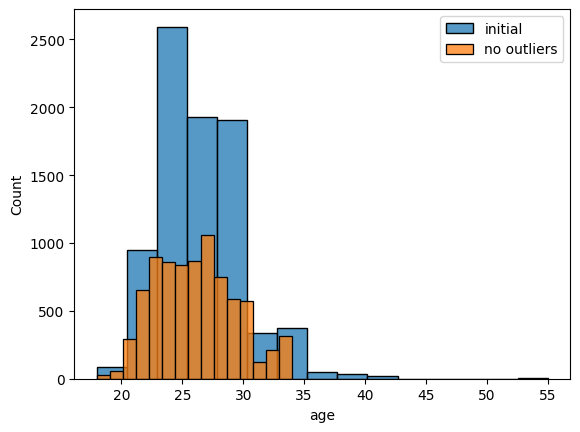

In [17]:
sns.histplot(x=data['age'], bins=15, label='initial')
sns.histplot(x=df_cleaned['age'], bins=15, label='no outliers')
plt.legend()

<Axes: xlabel='age', ylabel='gender'>

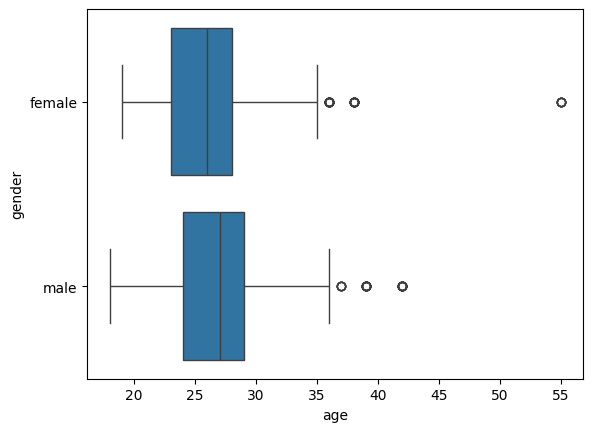

In [18]:
sns.boxplot(x=data['age'], y=data['gender'])


<Axes: xlabel='age', ylabel='gender'>

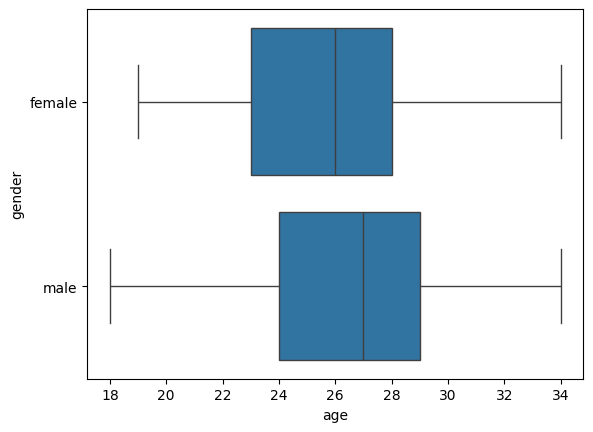

In [19]:
sns.boxplot(x=df_cleaned['age'], y=df_cleaned['gender'])

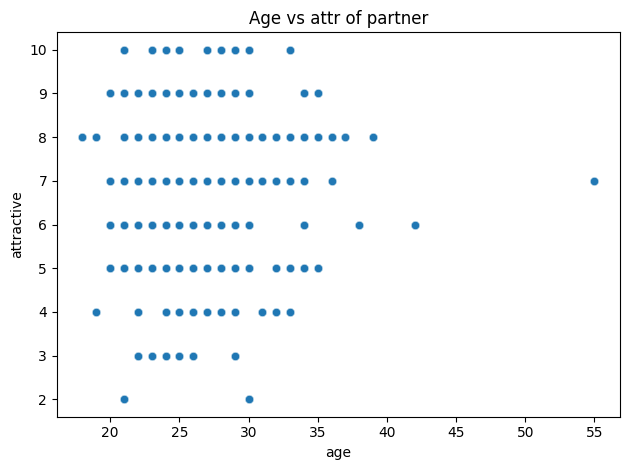

In [20]:
sns.scatterplot(data=data, x='age', y='attractive', alpha=0.5)
plt.title('Age vs attr of partner')
plt.tight_layout()
plt.show()

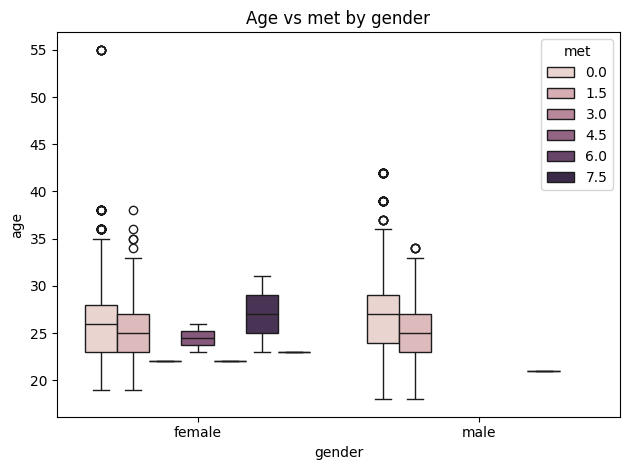

In [21]:
sns.boxplot(data=data, x='gender', y='age', hue='met')
plt.title('Age vs met by gender')
plt.tight_layout()
plt.show()

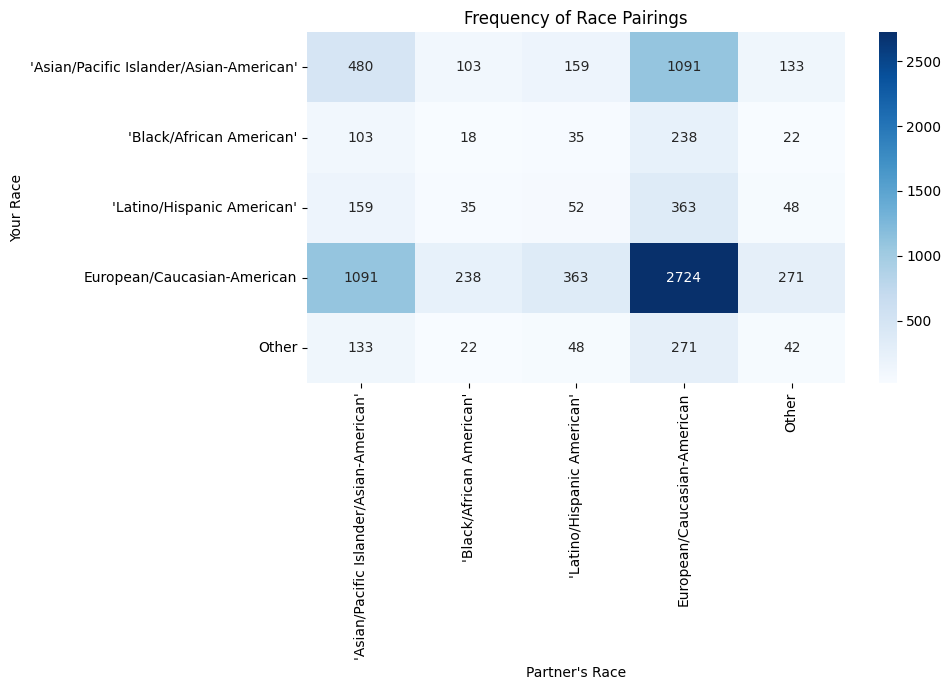

In [22]:
race_counts = data.groupby(['race', 'race_o']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 7))
sns.heatmap(race_counts, annot=True, fmt='d', cmap='Blues')
plt.title('Frequency of Race Pairings')
plt.xlabel('Partner\'s Race')
plt.ylabel('Your Race')
plt.tight_layout()
plt.show()

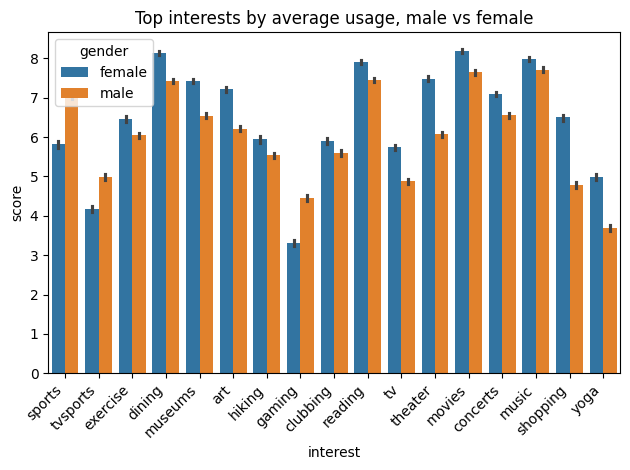

In [23]:
plot_df = data[
    ["gender"] + [
        'sports',
 'tvsports',
 'exercise',
 'dining',
 'museums',
 'art',
 'hiking',
 'gaming',
 'clubbing',
 'reading',
 'tv',
 'theater',
 'movies',
 'concerts',
 'music',
 'shopping',
 'yoga'
 ]
    ].melt(id_vars="gender", var_name="interest", value_name="score")
plt.figure()
sns.barplot(data=plot_df, x="interest", y="score", hue="gender", estimator=np.mean)
plt.xticks(rotation=45, ha="right")
plt.title("Top interests by average usage, male vs female")
plt.tight_layout()
plt.show()

met and match

In [24]:
g1= data.groupby("decision")[["met","match"]].mean().reset_index()
g1

,decision,met,match
0,0,0.033735,0.000000
1,1,0.071262,0.392268


In [25]:
g2 = data.groupby("decision_o")[["met","match"]].mean().reset_index()
g2

,decision_o,met,match
0,0,0.039113,0.000000
1,1,0.064393,0.392603


In [26]:
g3 = data.groupby(["decision","decision_o"])[["met","match"]].mean().reset_index()
g3

,decision,decision_o,met,match
0,0,0,0.034648,0.0
1,0,1,0.032619,0.0
2,1,0,0.044476,0.0
3,1,1,0.112843,1.0


In [27]:
na_data = data.isna().sum()
na_percent = (na_data / len(data)) * 100
na_percent[na_percent > 95]

Series([], dtype: float64)

## Analyse Missing Data

<Figure size 1200x600 with 0 Axes>

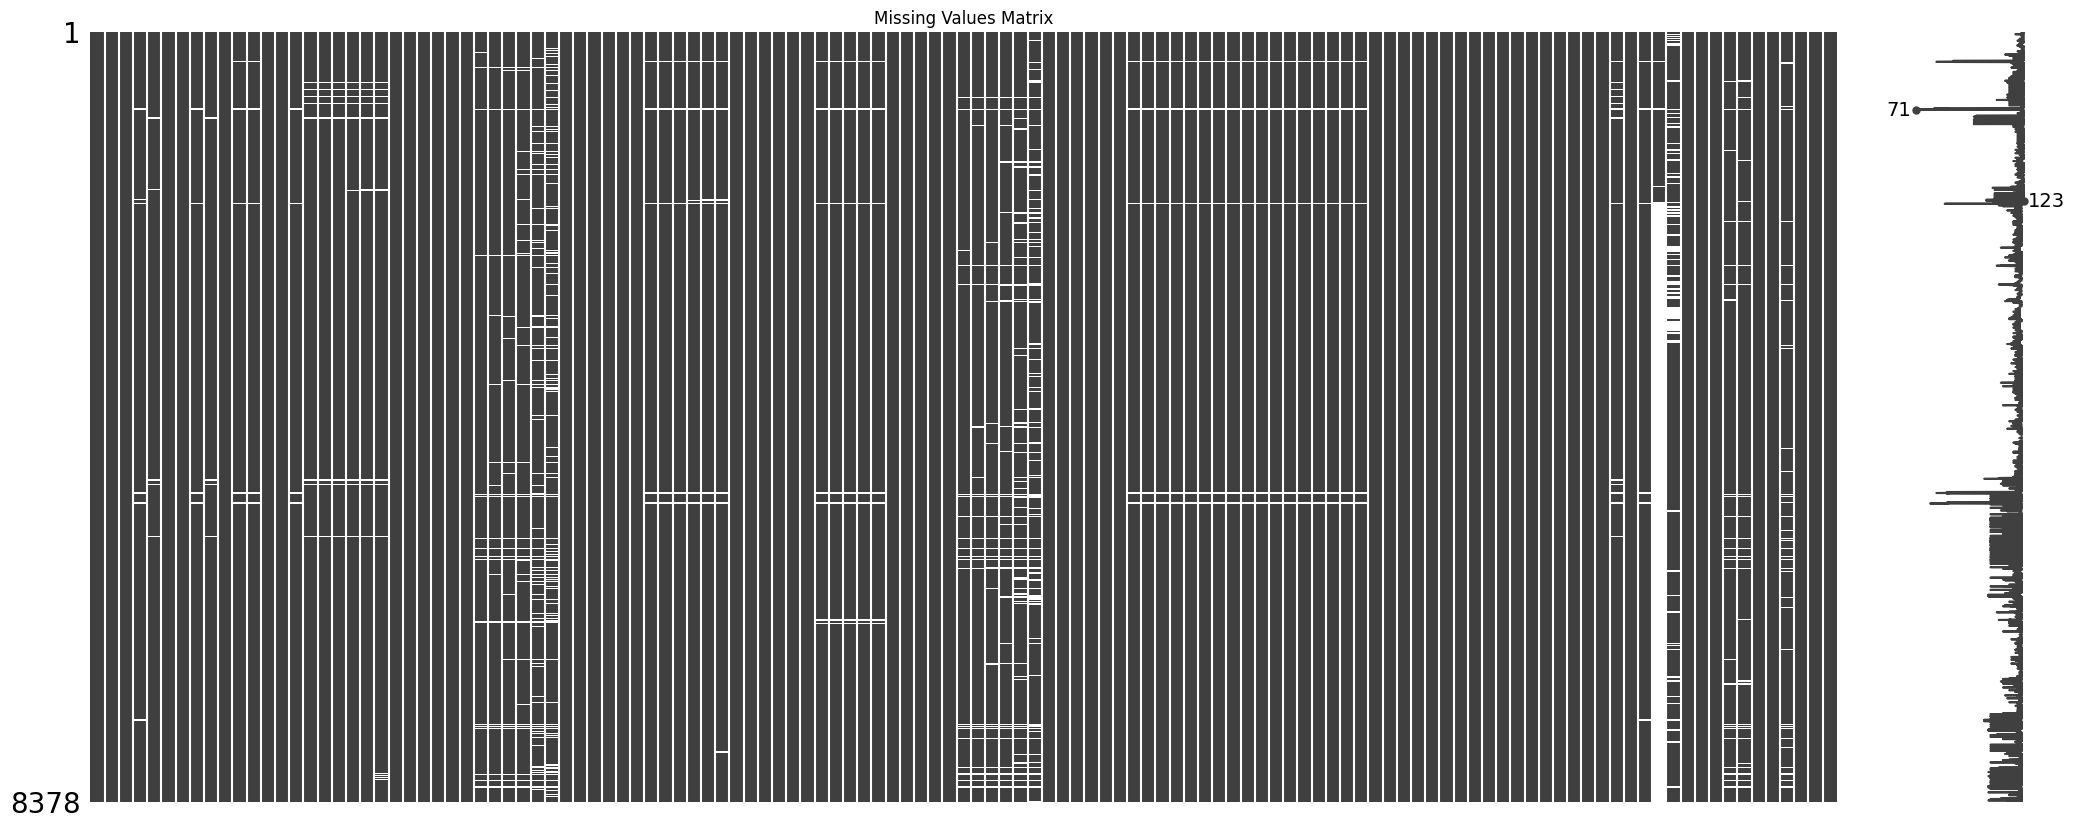

In [28]:
plt.figure(figsize=(12, 6))
msno.matrix(data)
plt.title('Missing Values Matrix')
plt.show()

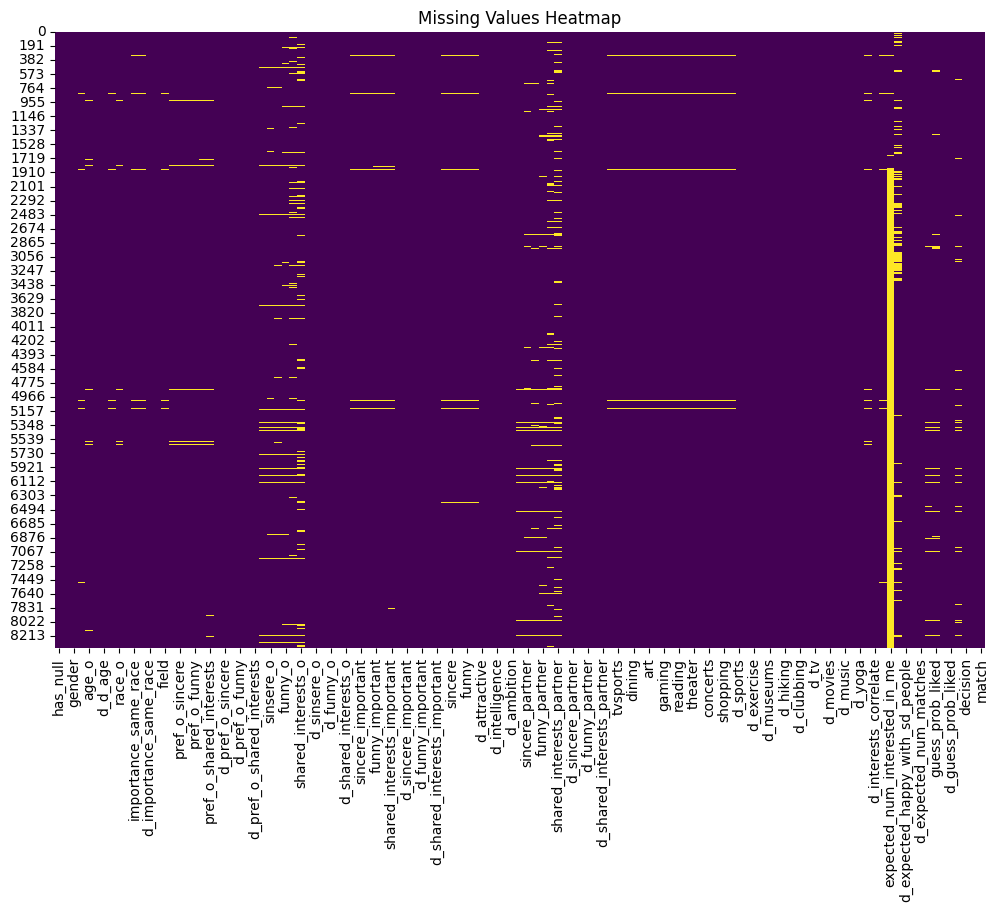

In [29]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

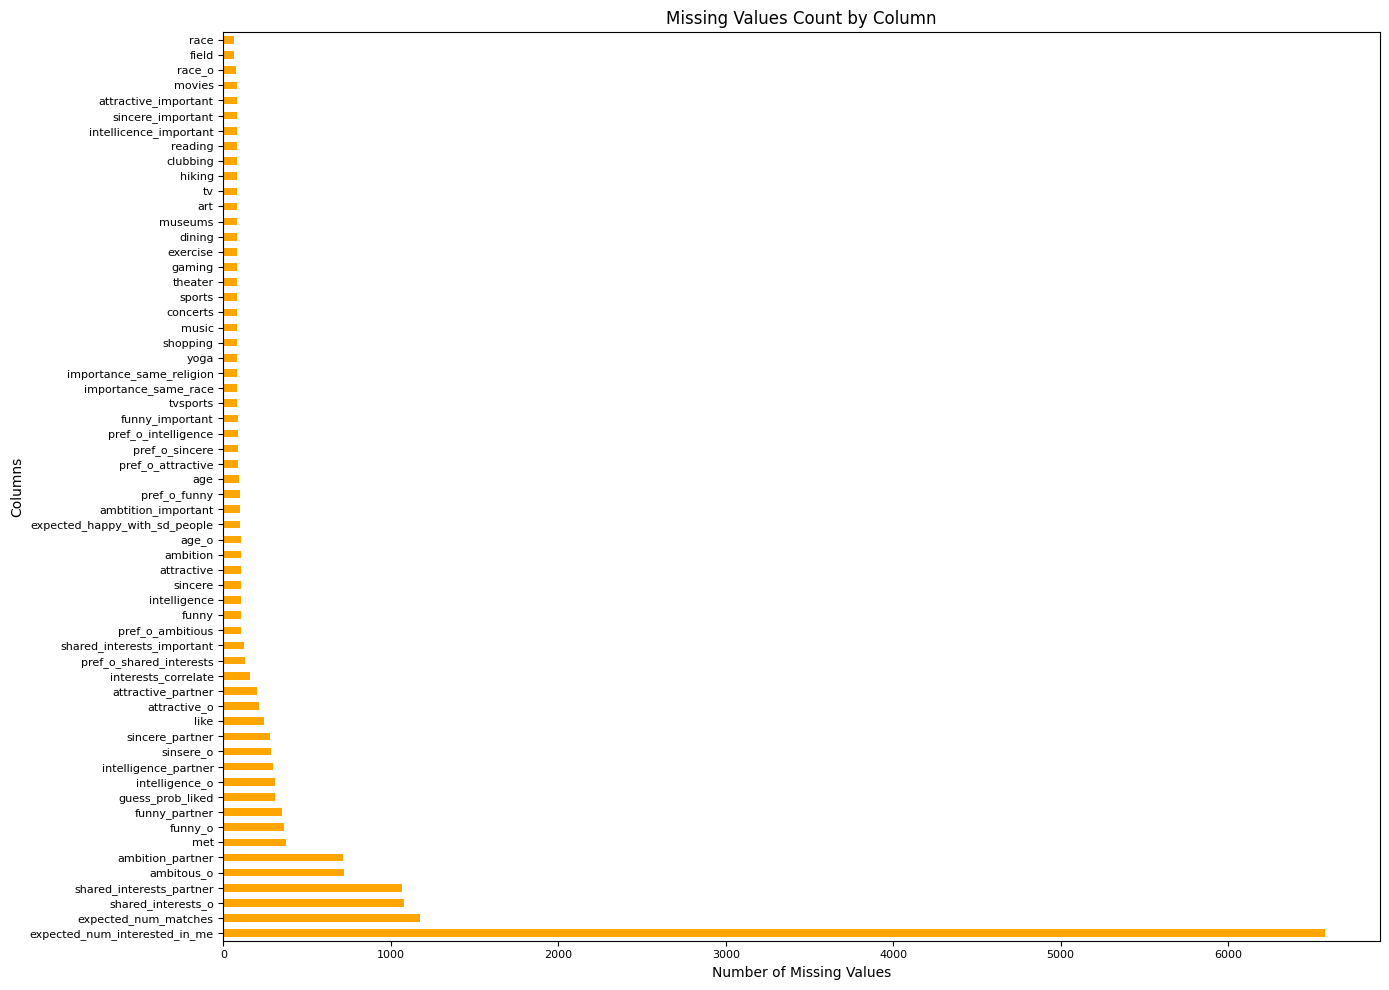

In [30]:
missing_values = data.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values.sort_values(inplace=True)

plt.figure(figsize=(14, 10))
missing_values.plot(kind='barh', color='orange')
plt.title('Missing Values Count by Column', fontsize=12)
plt.xlabel('Number of Missing Values', fontsize=10)
plt.ylabel('Columns', fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

there is a big number of missing values in the column expected_num_interests_in_me. Additionally, we did not find any relation to this missigness, so we assume to drop it

In [31]:
data.drop(columns=['expected_num_interested_in_me'], inplace=True)

returning to the patterns of missigness, it is seem, that there is MAR missigness. We see, that some data can be missed by the 80% of the string, but some occured just randomly. We consider to use imputation MICE algorithm for dealing with missing data

In [32]:
def get_missing_columns(df, columns_type):
  columns = df.select_dtypes(include=columns_type)
  has_missing_mask = columns.isnull().any() 
  missing_columns = has_missing_mask[has_missing_mask].index.tolist()
  return missing_columns

In [33]:
numerical_missing_columns = get_missing_columns(data, ['number'])
categorical_missing_values = get_missing_columns(data, ['object', 'string'])

print(f"Numerical missing values: {numerical_missing_columns}")
print(f"Categorical missing values: {categorical_missing_values}")

Numerical missing values: ['age', 'age_o', 'importance_same_race', 'importance_same_religion', 'pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence', 'pref_o_funny', 'pref_o_ambitious', 'pref_o_shared_interests', 'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o', 'attractive_important', 'sincere_important', 'intellicence_important', 'funny_important', 'ambtition_important', 'shared_interests_important', 'attractive', 'sincere', 'intelligence', 'funny', 'ambition', 'attractive_partner', 'sincere_partner', 'intelligence_partner', 'funny_partner', 'ambition_partner', 'shared_interests_partner', 'sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga', 'interests_correlate', 'expected_happy_with_sd_people', 'expected_num_matches', 'like', 'guess_prob_liked', 'met']
Categorical missing values: ['race', 'race_o', 'field']


In [34]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

numerical_df = data[numerical_missing_columns]

regressor = LinearRegression()
imp = IterativeImputer(random_state=42, max_iter=20)
Imputed_data = pd.DataFrame(imp.fit_transform(numerical_df), columns=numerical_missing_columns)

/Users/marta/Desktop/uni/speed_dating_zneus/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [35]:
df_no_nan = data.copy()

for column in Imputed_data.columns:
    df_no_nan[column] = Imputed_data[column]

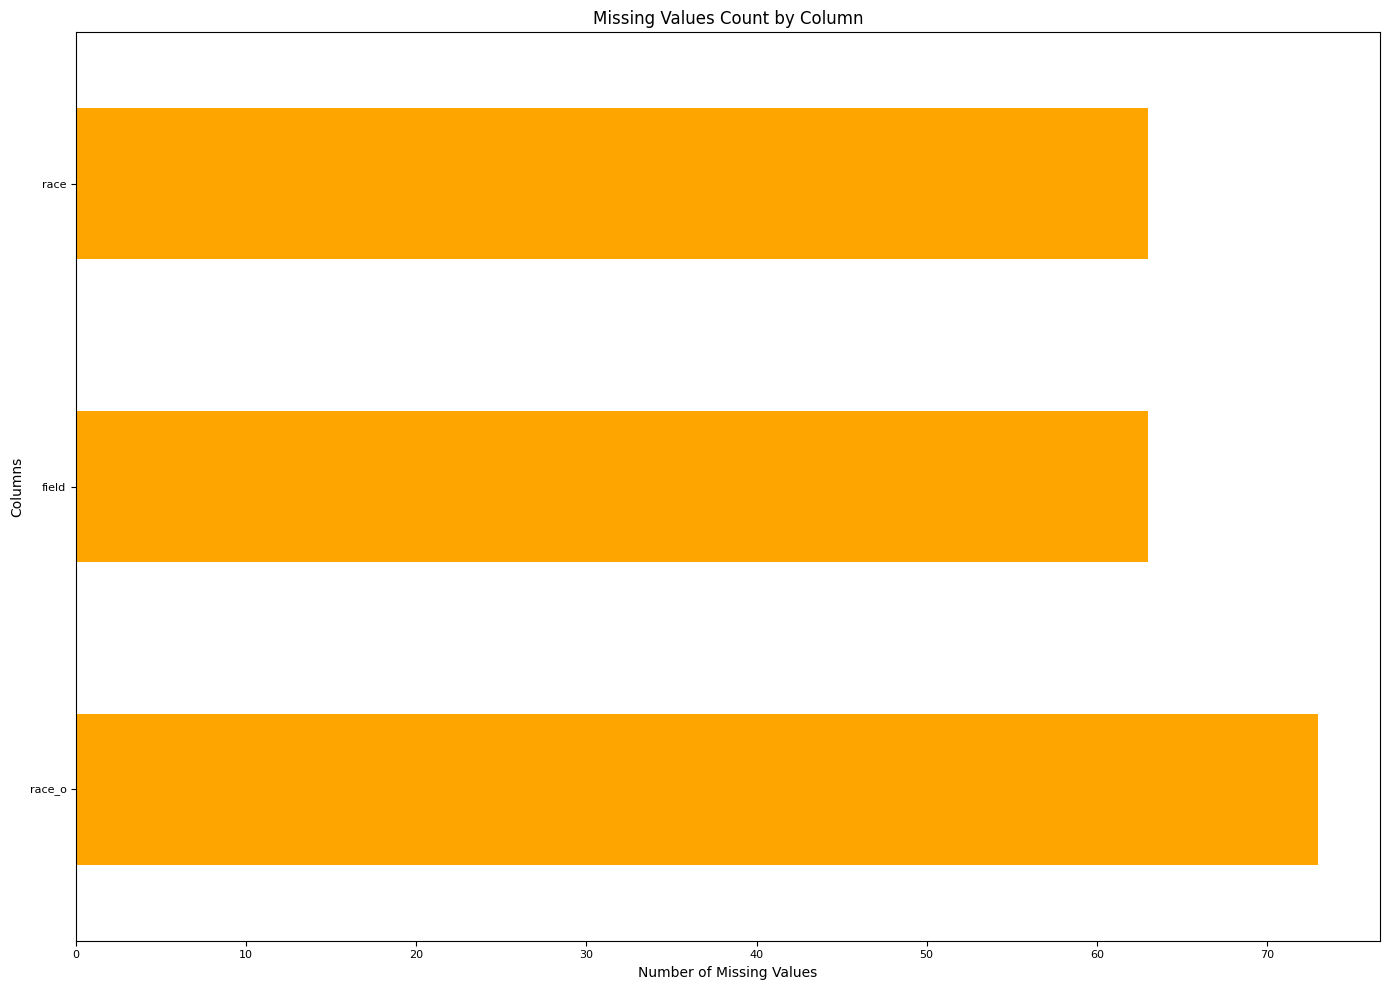

In [36]:
missing_values = df_no_nan.isnull().sum()
missing_values = missing_values[missing_values > 0]

if len(missing_values) > 0:
    missing_values.sort_values(inplace=True)
    
    plt.figure(figsize=(14, 10))
    missing_values.plot(kind='barh', color='orange')
    plt.title('Missing Values Count by Column', fontsize=12)
    plt.xlabel('Number of Missing Values', fontsize=10)
    plt.ylabel('Columns', fontsize=10)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## Analyse categorical data

In [37]:
categorical_columns = data.select_dtypes(include=['object', 'category']).columns
categorical_columns

Index(['gender', 'd_d_age', 'race', 'race_o', 'd_importance_same_race',
       'd_importance_same_religion', 'field', 'd_pref_o_attractive',
       'd_pref_o_sincere', 'd_pref_o_intelligence', 'd_pref_o_funny',
       'd_pref_o_ambitious', 'd_pref_o_shared_interests', 'd_attractive_o',
       'd_sinsere_o', 'd_intelligence_o', 'd_funny_o', 'd_ambitous_o',
       'd_shared_interests_o', 'd_attractive_important', 'd_sincere_important',
       'd_intellicence_important', 'd_funny_important',
       'd_ambtition_important', 'd_shared_interests_important', 'd_attractive',
       'd_sincere', 'd_intelligence', 'd_funny', 'd_ambition',
       'd_attractive_partner', 'd_sincere_partner', 'd_intelligence_partner',
       'd_funny_partner', 'd_ambition_partner', 'd_shared_interests_partner',
       'd_sports', 'd_tvsports', 'd_exercise', 'd_dining', 'd_museums',
       'd_art', 'd_hiking', 'd_gaming', 'd_clubbing', 'd_reading', 'd_tv',
       'd_theater', 'd_movies', 'd_concerts', 'd_music', 'd_

### Columns cleaning

We found out, that there are the main parameters, that are observed in the dataset which are:\
intelligence, attractive, sincere, funny, ambition, shared_interests

I noticed the errors in some namings. So in this section we will transform the namings to fit the names and for the easier namings

In [39]:
parameters = ["intelligence", "attractive", "sincere", "funny", "ambition", "shared_interests"]

In [40]:
unified_parameters = {}
for param in parameters:
  param_correlations = []
  partner_param_importance = f"pref_o_{param}"
  my_param_importance = f"{param}_important"
  partner_param_evaluation = f"{param}_o"
  my_param_evaluation = f"{param}_partner"
  params = [partner_param_importance, my_param_importance, partner_param_evaluation, my_param_evaluation]
  unified_parameters[param] = params
  
  for p in params:
      if p not in data.columns:
          print(f"Column {p} not found in data.")

Column intelligence_important not found in data.
Column sincere_o not found in data.
Column pref_o_ambition not found in data.
Column ambition_important not found in data.
Column ambition_o not found in data.


In [41]:
unified_d_parameters = {}
for param in parameters:
  param_correlations = []
  partner_param_importance = f"d_pref_o_{param}"
  my_param_importance = f"d_{param}_important"
  partner_param_evaluation = f"d_{param}_o"
  my_param_evaluation = f"d_{param}_partner"
  params = [partner_param_importance, my_param_importance, partner_param_evaluation, my_param_evaluation]
  unified_d_parameters[param] = params
  
  for p in params:
      if p not in data.columns:
          print(f"Column {p} not found in data.")

Column d_intelligence_important not found in data.
Column d_sincere_o not found in data.
Column d_pref_o_ambition not found in data.
Column d_ambition_important not found in data.
Column d_ambition_o not found in data.


In [42]:
cleaned_df = data.copy()
cleaned_df = cleaned_df.rename(columns={
  "intellicence_important": "intelligence_important",
  "d_intellicence_important": "d_intelligence_important",
  "sinsere_o": "sincere_o",
  "d_sinsere_o": "d_sincere_o",
  "pref_o_ambitious": "pref_o_ambition",
  "d_pref_o_ambitious": "d_pref_o_ambition",
  "ambtition_important": "ambition_important",
  "d_ambtition_important": "d_ambition_important",
  "ambitous_o": "ambition_o",
  "d_ambitous_o": "d_ambition_o",
})

cleaned_df.head()

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,0,1,female,21.0,27.0,6,[4-6],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,...,[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1,0,0
1,0,1,female,21.0,22.0,1,[0-1],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,...,[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0,1,0,0
2,1,1,female,21.0,22.0,1,[0-1],'Asian/Pacific Islander/Asian-American','Asian/Pacific Islander/Asian-American',1,...,[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0,1,1,1
3,0,1,female,21.0,23.0,2,[2-3],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,...,[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1,1,1
4,0,1,female,21.0,24.0,3,[2-3],'Asian/Pacific Islander/Asian-American','Latino/Hispanic American',0,...,[0-3],[3-5],6.0,6.0,[6-8],[5-6],0.0,1,1,1


We cleaned the columns naming, now we will reame them to be easier for understanding

In [43]:
def rename_to_prefered_name(df, column_name, prefered_name):
    df.rename(columns={column_name: prefered_name}, inplace=True)

In [44]:
unified_parameters = {}
for param in parameters:
  rename_to_prefered_name(cleaned_df, f"pref_o_{param}", f"{param}_important_o")
  rename_to_prefered_name(cleaned_df, f"{param}_o", f"p_eval_of_my_{param}")
  rename_to_prefered_name(cleaned_df, f"{param}_partner", f"my_eval_of_p_{param}")
  partner_param_importance = f"{param}_important_o"
  my_param_importance = f"{param}_important"
  partner_param_evaluation = f"p_eval_of_my_{param}"
  my_param_evaluation = f"my_eval_of_p_{param}"
  params = [partner_param_importance, my_param_importance, partner_param_evaluation, my_param_evaluation]
  unified_parameters[param] = params

unified_parameters

{'intelligence': ['intelligence_important_o',
  'intelligence_important',
  'p_eval_of_my_intelligence',
  'my_eval_of_p_intelligence'],
 'attractive': ['attractive_important_o',
  'attractive_important',
  'p_eval_of_my_attractive',
  'my_eval_of_p_attractive'],
 'sincere': ['sincere_important_o',
  'sincere_important',
  'p_eval_of_my_sincere',
  'my_eval_of_p_sincere'],
 'funny': ['funny_important_o',
  'funny_important',
  'p_eval_of_my_funny',
  'my_eval_of_p_funny'],
 'ambition': ['ambition_important_o',
  'ambition_important',
  'p_eval_of_my_ambition',
  'my_eval_of_p_ambition'],
 'shared_interests': ['shared_interests_important_o',
  'shared_interests_important',
  'p_eval_of_my_shared_interests',
  'my_eval_of_p_shared_interests']}

In [45]:
unified_d_parameters = {}

for param in parameters:
  rename_to_prefered_name(cleaned_df, f"d_pref_o_{param}", f"d_{param}_important_o")
  rename_to_prefered_name(cleaned_df, f"d_{param}_o", f"d_p_eval_of_my_{param}")
  rename_to_prefered_name(cleaned_df, f"d_{param}_partner", f"d_my_eval_of_p_{param}")
  partner_param_importance = f"d_{param}_important_o"
  my_param_importance = f"d_{param}_important"
  partner_param_evaluation = f"d_p_eval_of_my_{param}"
  my_param_evaluation = f"d_my_eval_of_p_{param}"
  params = [partner_param_importance, my_param_importance, partner_param_evaluation, my_param_evaluation]
  unified_d_parameters[param] = params

unified_d_parameters

{'intelligence': ['d_intelligence_important_o',
  'd_intelligence_important',
  'd_p_eval_of_my_intelligence',
  'd_my_eval_of_p_intelligence'],
 'attractive': ['d_attractive_important_o',
  'd_attractive_important',
  'd_p_eval_of_my_attractive',
  'd_my_eval_of_p_attractive'],
 'sincere': ['d_sincere_important_o',
  'd_sincere_important',
  'd_p_eval_of_my_sincere',
  'd_my_eval_of_p_sincere'],
 'funny': ['d_funny_important_o',
  'd_funny_important',
  'd_p_eval_of_my_funny',
  'd_my_eval_of_p_funny'],
 'ambition': ['d_ambition_important_o',
  'd_ambition_important',
  'd_p_eval_of_my_ambition',
  'd_my_eval_of_p_ambition'],
 'shared_interests': ['d_shared_interests_important_o',
  'd_shared_interests_important',
  'd_p_eval_of_my_shared_interests',
  'd_my_eval_of_p_shared_interests']}

In [46]:
print(cleaned_df.columns.tolist())

['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age', 'race', 'race_o', 'samerace', 'importance_same_race', 'importance_same_religion', 'd_importance_same_race', 'd_importance_same_religion', 'field', 'attractive_important_o', 'sincere_important_o', 'intelligence_important_o', 'funny_important_o', 'ambition_important_o', 'shared_interests_important_o', 'd_attractive_important_o', 'd_sincere_important_o', 'd_intelligence_important_o', 'd_funny_important_o', 'd_ambition_important_o', 'd_shared_interests_important_o', 'p_eval_of_my_attractive', 'p_eval_of_my_sincere', 'p_eval_of_my_intelligence', 'p_eval_of_my_funny', 'p_eval_of_my_ambition', 'p_eval_of_my_shared_interests', 'd_p_eval_of_my_attractive', 'd_p_eval_of_my_sincere', 'd_p_eval_of_my_intelligence', 'd_p_eval_of_my_funny', 'd_p_eval_of_my_ambition', 'd_p_eval_of_my_shared_interests', 'attractive_important', 'sincere_important', 'intelligence_important', 'funny_important', 'ambition_important', 'shared_interests_impo

In [47]:
for param in parameters:
    cols = unified_parameters[param]
    for col in cols:
        missing_values_count = cleaned_df[cleaned_df[col].isna()].shape[0]
        percentage_missing = (missing_values_count / len(cleaned_df)) * 100
        print(f"{col}: {missing_values_count} missing values; {percentage_missing:.2f}%")

intelligence_important_o: 89 missing values; 1.06%
intelligence_important: 79 missing values; 0.94%
p_eval_of_my_intelligence: 306 missing values; 3.65%
my_eval_of_p_intelligence: 296 missing values; 3.53%
attractive_important_o: 89 missing values; 1.06%
attractive_important: 79 missing values; 0.94%
p_eval_of_my_attractive: 212 missing values; 2.53%
my_eval_of_p_attractive: 202 missing values; 2.41%
sincere_important_o: 89 missing values; 1.06%
sincere_important: 79 missing values; 0.94%
p_eval_of_my_sincere: 287 missing values; 3.43%
my_eval_of_p_sincere: 277 missing values; 3.31%
funny_important_o: 98 missing values; 1.17%
funny_important: 89 missing values; 1.06%
p_eval_of_my_funny: 360 missing values; 4.30%
my_eval_of_p_funny: 350 missing values; 4.18%
ambition_important_o: 107 missing values; 1.28%
ambition_important: 99 missing values; 1.18%
p_eval_of_my_ambition: 722 missing values; 8.62%
my_eval_of_p_ambition: 712 missing values; 8.50%
shared_interests_important_o: 129 missing

In [48]:
threshold = 0.8
min_non_na = int((1 - threshold) * len(cleaned_df.columns))
cleaned_df = cleaned_df.dropna(thresh=min_non_na)

In [49]:
for param in parameters:
    cols = unified_parameters[param]
    for col in cols:
        missing_values_count = cleaned_df[cleaned_df[col].isna()].shape[0]
        if missing_values_count == 0:
            print(f"{col}: No missing values")
            continue
        percentage_missing = (missing_values_count / len(cleaned_df)) * 100
        print(f"{col}: {missing_values_count} missing values; {percentage_missing:.2f}%")

intelligence_important_o: 89 missing values; 1.06%
intelligence_important: 79 missing values; 0.94%
p_eval_of_my_intelligence: 306 missing values; 3.65%
my_eval_of_p_intelligence: 296 missing values; 3.53%
attractive_important_o: 89 missing values; 1.06%
attractive_important: 79 missing values; 0.94%
p_eval_of_my_attractive: 212 missing values; 2.53%
my_eval_of_p_attractive: 202 missing values; 2.41%
sincere_important_o: 89 missing values; 1.06%
sincere_important: 79 missing values; 0.94%
p_eval_of_my_sincere: 287 missing values; 3.43%
my_eval_of_p_sincere: 277 missing values; 3.31%
funny_important_o: 98 missing values; 1.17%
funny_important: 89 missing values; 1.06%
p_eval_of_my_funny: 360 missing values; 4.30%
my_eval_of_p_funny: 350 missing values; 4.18%
ambition_important_o: 107 missing values; 1.28%
ambition_important: 99 missing values; 1.18%
p_eval_of_my_ambition: 722 missing values; 8.62%
my_eval_of_p_ambition: 712 missing values; 8.50%
shared_interests_important_o: 129 missing

### Check for the data content

In [50]:
categorical_df = cleaned_df.select_dtypes(include=['object', 'category'])
categorical_df.head()

,gender,d_d_age,race,race_o,d_importance_same_race,d_importance_same_religion,field,d_attractive_important_o,d_sincere_important_o,d_intelligence_important_o,...,d_concerts,d_music,d_shopping,d_yoga,d_interests_correlate,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,d_like,d_guess_prob_liked
0,female,[4-6],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,[2-5],[2-5],Law,[21-100],[16-20],[16-20],...,[9-10],[9-10],[6-8],[0-5],[0-0.33],[0-4],[0-3],[3-5],[6-8],[5-6]
1,female,[0-1],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,[2-5],[2-5],Law,[21-100],[0-15],[0-15],...,[9-10],[9-10],[6-8],[0-5],[0.33-1],[0-4],[0-3],[3-5],[6-8],[5-6]
2,female,[0-1],'Asian/Pacific Islander/Asian-American','Asian/Pacific Islander/Asian-American',[2-5],[2-5],Law,[16-20],[16-20],[16-20],...,[9-10],[9-10],[6-8],[0-5],[0-0.33],[0-4],[0-3],[3-5],[6-8],[0-4]
3,female,[2-3],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,[2-5],[2-5],Law,[21-100],[0-15],[0-15],...,[9-10],[9-10],[6-8],[0-5],[0.33-1],[0-4],[0-3],[3-5],[6-8],[5-6]
4,female,[2-3],'Asian/Pacific Islander/Asian-American','Latino/Hispanic American',[2-5],[2-5],Law,[21-100],[0-15],[16-20],...,[9-10],[9-10],[6-8],[0-5],[0-0.33],[0-4],[0-3],[3-5],[6-8],[5-6]


In [51]:
categorical_columns = categorical_df.columns.tolist()
categorical_columns

['gender',
 'd_d_age',
 'race',
 'race_o',
 'd_importance_same_race',
 'd_importance_same_religion',
 'field',
 'd_attractive_important_o',
 'd_sincere_important_o',
 'd_intelligence_important_o',
 'd_funny_important_o',
 'd_ambition_important_o',
 'd_shared_interests_important_o',
 'd_p_eval_of_my_attractive',
 'd_p_eval_of_my_sincere',
 'd_p_eval_of_my_intelligence',
 'd_p_eval_of_my_funny',
 'd_p_eval_of_my_ambition',
 'd_p_eval_of_my_shared_interests',
 'd_attractive_important',
 'd_sincere_important',
 'd_intelligence_important',
 'd_funny_important',
 'd_ambition_important',
 'd_shared_interests_important',
 'd_attractive',
 'd_sincere',
 'd_intelligence',
 'd_funny',
 'd_ambition',
 'd_my_eval_of_p_attractive',
 'd_my_eval_of_p_sincere',
 'd_my_eval_of_p_intelligence',
 'd_my_eval_of_p_funny',
 'd_my_eval_of_p_ambition',
 'd_my_eval_of_p_shared_interests',
 'd_sports',
 'd_tvsports',
 'd_exercise',
 'd_dining',
 'd_museums',
 'd_art',
 'd_hiking',
 'd_gaming',
 'd_clubbing',
 'd

In [52]:
categorical_df.nunique()

gender                               2
d_d_age                              4
race                                 5
race_o                               5
d_importance_same_race               3
d_importance_same_religion           3
field                              259
d_attractive_important_o             3
d_sincere_important_o                3
d_intelligence_important_o           3
d_funny_important_o                  3
d_ambition_important_o               3
d_shared_interests_important_o       3
d_p_eval_of_my_attractive            3
d_p_eval_of_my_sincere               3
d_p_eval_of_my_intelligence          3
d_p_eval_of_my_funny                 3
d_p_eval_of_my_ambition              3
d_p_eval_of_my_shared_interests      3
d_attractive_important               3
d_sincere_important                  3
d_intelligence_important             3
d_funny_important                    3
d_ambition_important                 3
d_shared_interests_important         3
d_attractive             

In [53]:
cols_unique_values = {}

for col in categorical_df.columns:
    unique_vals = categorical_df[col].unique()
    print(f"{col}: {len(unique_vals)}\n{unique_vals}\n")


gender: 2
['female' 'male']

d_d_age: 4
['[4-6]' '[0-1]' '[2-3]' '[7-37]']

race: 6
["'Asian/Pacific Islander/Asian-American'" 'European/Caucasian-American'
 'Other' "'Latino/Hispanic American'" "'Black/African American'" nan]

race_o: 6
['European/Caucasian-American' "'Asian/Pacific Islander/Asian-American'"
 "'Latino/Hispanic American'" 'Other' "'Black/African American'" nan]

d_importance_same_race: 3
['[2-5]' '[6-10]' '[0-1]']

d_importance_same_religion: 3
['[2-5]' '[0-1]' '[6-10]']

field: 260
['Law' 'law' 'Economics' "'Masters in Public Administration'"
 "'Masters of Social Work&Education'" 'Finance' 'Business'
 "'political science'" 'money' "'Operations Research'" "'TC [Health Ed]'"
 'Psychology' "'social work'" "'Social Work'"
 "'Speech Language Pathology'" "'Speech Languahe Pathology'"
 "'Educational Psychology'" "'Applied Maths/Econs'" 'Mathematics'
 'Statistics' "'Organizational Psychology'" "'Mechanical Engineering'"
 'Finanace' 'Finance&Economics' "'Undergrad - GS'"
 "'Ma

According to the unique values represented for each categorical data field now we can divide them into 4 categorical group types:
1. Nominal data: gender, race, race_o, field (which is probably represent the job of person)
2. Ordinal data: - all the left fields are related to ratio data, since they cannot be less than 0 and represent some intervals. Despite, that these data re represented as ranges-string thay are follow in ascending order, so we can speak about them as ordinal data.

According to the received info we can proceed on working on data by the type of category.

### Nominal data

#### gender

In [54]:
match_between_genders = cleaned_df.groupby(['match', 'gender']).size().unstack(fill_value=0)
match_between_genders

gender,female,male
match,,
0,3494,3504
1,690,690


In [55]:
match_percentages = (cleaned_df.groupby(['match', 'gender']).size().unstack(fill_value=0)
                     .div(cleaned_df.groupby('match').size(), axis=0) * 100)
match_percentages

gender,female,male
match,,
0,49.928551,50.071449
1,50.000000,50.000000


<Figure size 1000x600 with 0 Axes>

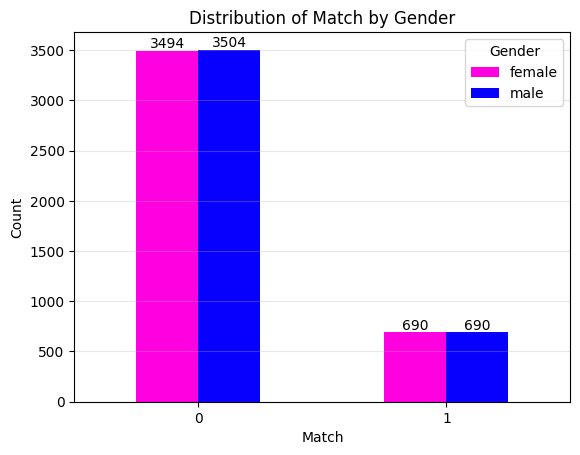

In [56]:
plt.figure(figsize=(10, 6))
ax = match_between_genders.plot(kind='bar', color=["#FF00E1", "#0800FF"])
plt.title('Distribution of Match by Gender')
plt.xlabel('Match')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, label_type='edge')


plt.show()

<Figure size 1000x600 with 0 Axes>

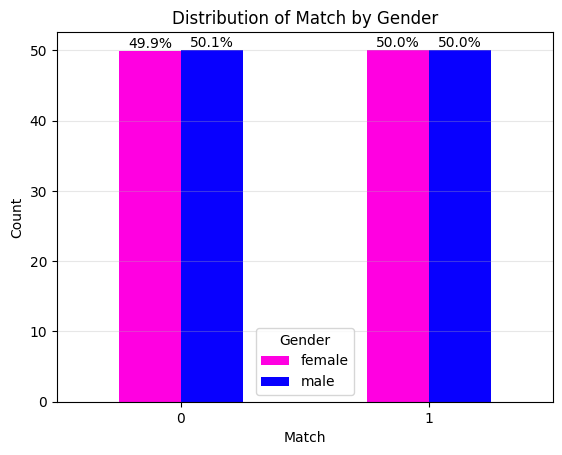

In [57]:
plt.figure(figsize=(10, 6))
ax = match_percentages.plot(kind='bar', color=["#FF00E1", "#0800FF"])
plt.title('Distribution of Match by Gender')
plt.xlabel('Match')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type='edge')


plt.show()

In [58]:
gender_encoded = pd.get_dummies(categorical_df, columns=['gender'])
gender_encoded.head()

,d_d_age,race,race_o,d_importance_same_race,d_importance_same_religion,field,d_attractive_important_o,d_sincere_important_o,d_intelligence_important_o,d_funny_important_o,...,d_shopping,d_yoga,d_interests_correlate,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,d_like,d_guess_prob_liked,gender_female,gender_male
0,[4-6],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,[2-5],[2-5],Law,[21-100],[16-20],[16-20],[16-20],...,[6-8],[0-5],[0-0.33],[0-4],[0-3],[3-5],[6-8],[5-6],True,False
1,[0-1],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,[2-5],[2-5],Law,[21-100],[0-15],[0-15],[21-100],...,[6-8],[0-5],[0.33-1],[0-4],[0-3],[3-5],[6-8],[5-6],True,False
2,[0-1],'Asian/Pacific Islander/Asian-American','Asian/Pacific Islander/Asian-American',[2-5],[2-5],Law,[16-20],[16-20],[16-20],[16-20],...,[6-8],[0-5],[0-0.33],[0-4],[0-3],[3-5],[6-8],[0-4],True,False
3,[2-3],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,[2-5],[2-5],Law,[21-100],[0-15],[0-15],[21-100],...,[6-8],[0-5],[0.33-1],[0-4],[0-3],[3-5],[6-8],[5-6],True,False
4,[2-3],'Asian/Pacific Islander/Asian-American','Latino/Hispanic American',[2-5],[2-5],Law,[21-100],[0-15],[16-20],[0-15],...,[6-8],[0-5],[0-0.33],[0-4],[0-3],[3-5],[6-8],[5-6],True,False


It is clearly seen from the unique values, that we can indicate about 12 types of jobs. We will try to cluster them to unify to some 12 categories for the better processing them in the future model

### Correlations between variables and match

1. Use chi-square test to to determine if there is a significant association between each variable and target(match)
2. On the base of chi-square test result use Cramer's V test to measure the association between each variable and match - calculation of correlations 

In [59]:
def chi_square_test(var1, var2):
    """Perform Chi-Square test of independence"""
    confusion_matrix = pd.crosstab(var1, var2)
    chi2, _, _, _ = chi2_contingency(confusion_matrix)
    return chi2, confusion_matrix

In [60]:
def cramerV(label, x):
    chi2, confusion_matrix = chi_square_test(label, x)
    n = confusion_matrix.sum().sum()
    minDim = min(confusion_matrix.shape) - 1
    V = np.sqrt((chi2 / n) / minDim)
    return V

In [61]:
correlation_results = {}

for col in categorical_columns:
    correlation_results[col] = cramerV(categorical_df[col], cleaned_df['match'])

categorical_correlations = pd.DataFrame.from_dict(correlation_results, orient='index', columns=['correlation'])
print(categorical_correlations)

                                 correlation
gender                              0.000208
d_d_age                             0.059045
race                                0.053206
race_o                              0.053052
d_importance_same_race              0.050103
d_importance_same_religion          0.026590
field                               0.270954
d_attractive_important_o            0.012038
d_sincere_important_o               0.033875
d_intelligence_important_o          0.030044
d_funny_important_o                 0.037788
d_ambition_important_o              0.026638
d_shared_interests_important_o      0.029798
d_p_eval_of_my_attractive           0.243230
d_p_eval_of_my_sincere              0.156340
d_p_eval_of_my_intelligence         0.163777
d_p_eval_of_my_funny                0.266513
d_p_eval_of_my_ambition             0.135391
d_p_eval_of_my_shared_interests     0.252182
d_attractive_important              0.013134
d_sincere_important                 0.034242
d_intellig

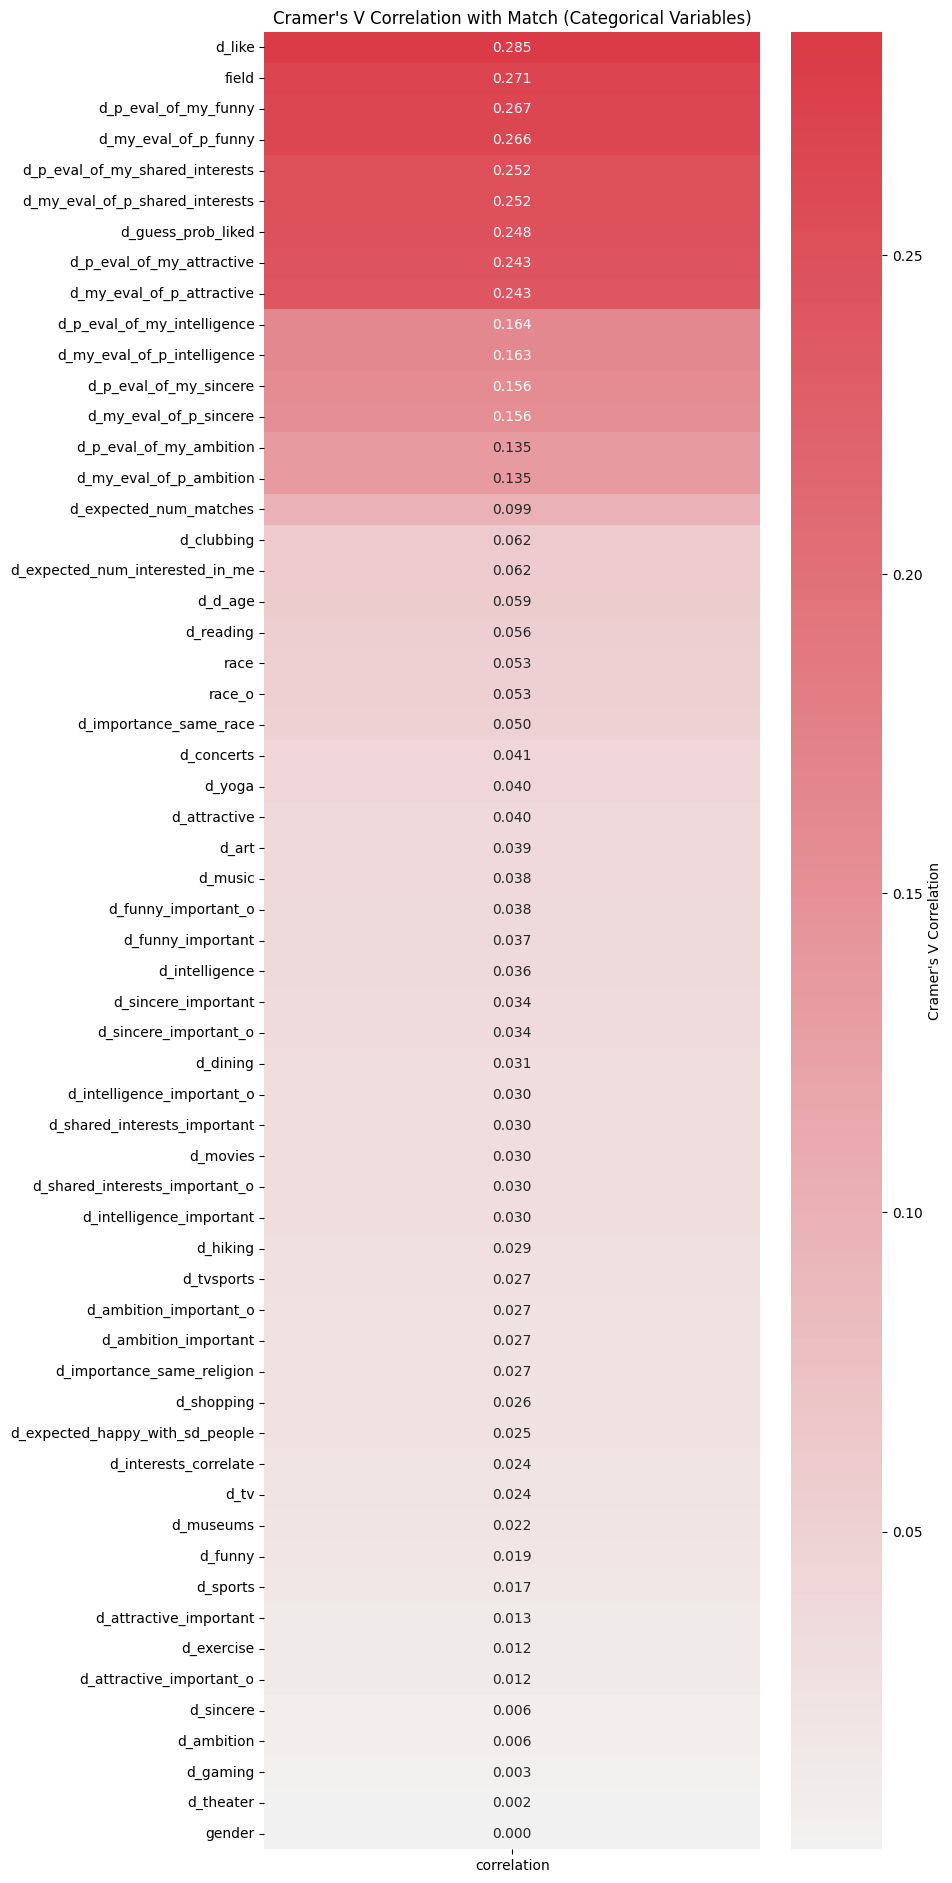

In [62]:
categorical_correlations_sorted = categorical_correlations.sort_values('correlation', ascending=False)
cmap = sns.diverging_palette(110, 10, as_cmap=True)

n_variables = len(categorical_correlations_sorted)
plt.figure(figsize=(8, max(6, n_variables * 0.4)))
sns.heatmap(categorical_correlations_sorted, 
            annot=True,
            cmap=cmap,
            center=0,
            fmt='.3f',
            cbar_kws={'label': "Cramer's V Correlation"})
plt.title('Cramer\'s V Correlation with Match (Categorical Variables)')
plt.show()

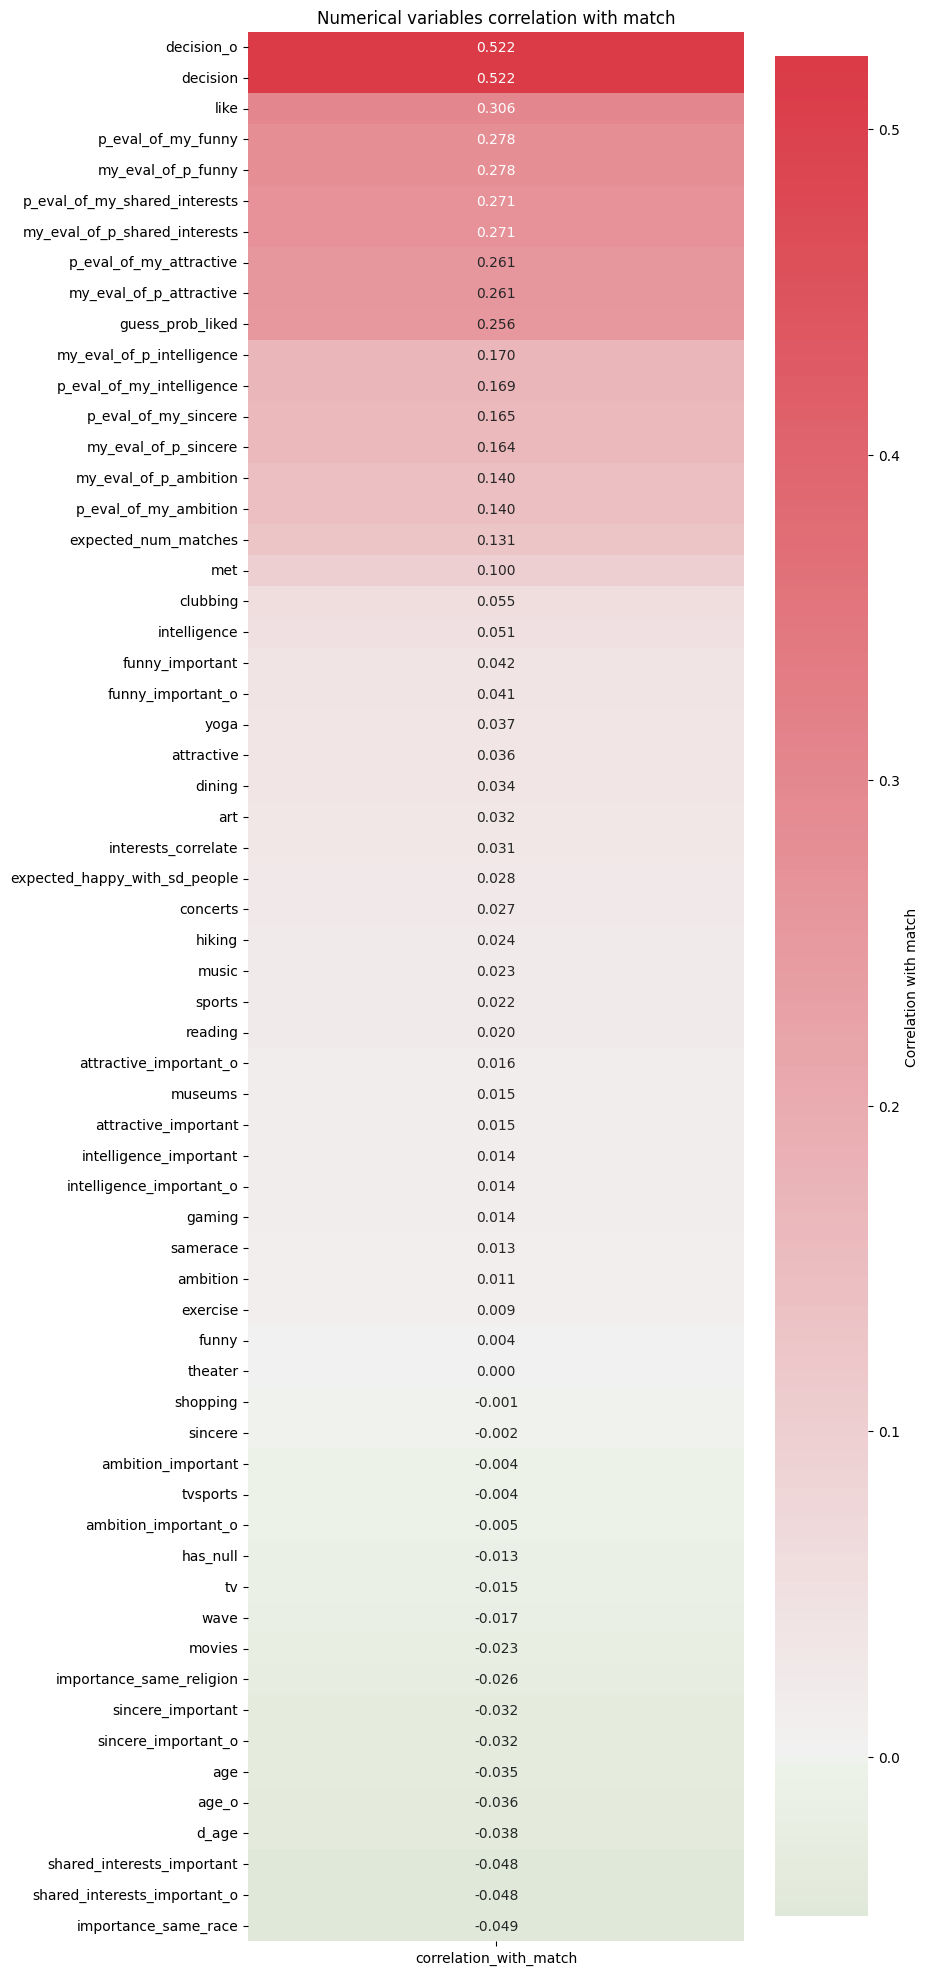

In [63]:
numeric_columns = cleaned_df.select_dtypes(include=['number']).columns
numeric_corr_match = cleaned_df[numeric_columns].corr()['match'].drop('match').sort_values(ascending=False)
corr_df = numeric_corr_match.to_frame('correlation_with_match')

cmap = sns.diverging_palette(110, 10, as_cmap=True)

n_variables = len(corr_df)
plt.figure(figsize=(8, max(6, n_variables * 0.4)))
sns.heatmap(corr_df, 
            annot=True,
            cmap=cmap,
            center=0,
            fmt='.3f',
            cbar_kws={'label': "Correlation with match"})
plt.title('Numerical variables correlation with match')
plt.show()

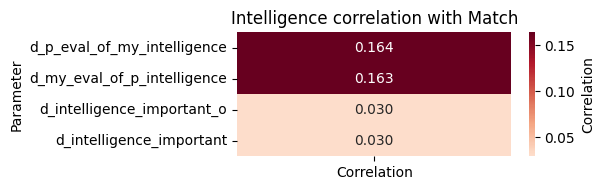

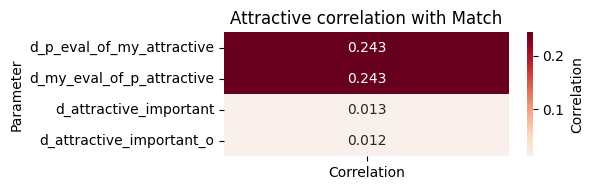

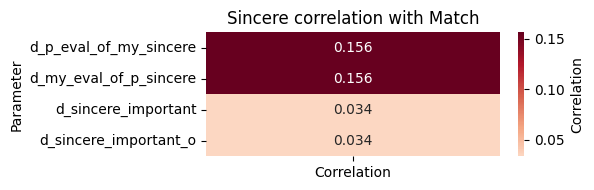

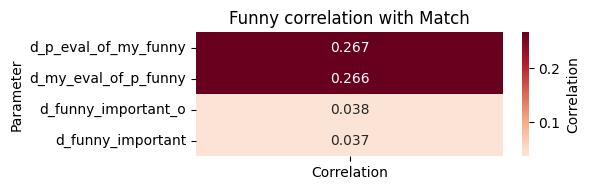

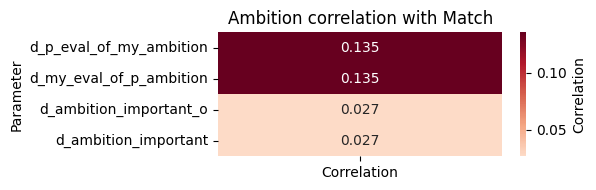

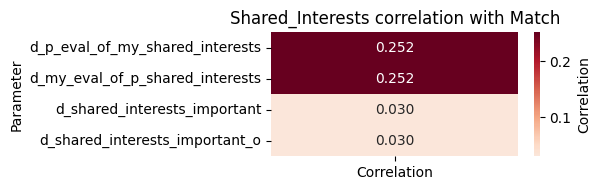

In [64]:
correlations_total = {}

for param in unified_d_parameters:
    correlations = {}
    correlations_total[param] = []
    for p in unified_d_parameters[param]:
        if p in cleaned_df.columns:
            correlations[p] = cramerV(cleaned_df[p], cleaned_df['match'])
            correlations_total[param].append({p: correlations[p]})
    
    if correlations:
        plot_df = pd.DataFrame(list(correlations.items()), 
                             columns=['Parameter', 'Correlation'])
        plot_df = plot_df.sort_values(by='Correlation', ascending=False)
        plot_df = plot_df.set_index('Parameter')
        
        # Heatmap
        plt.figure(figsize=(6, 2))
        sns.heatmap(plot_df, 
                    annot=True, 
                    center=0, 
                    fmt='.3f', 
                    cmap='RdBu_r',
                    cbar_kws={'label': 'Correlation'})
        plt.title(f'{param.title()} correlation with Match')
        plt.tight_layout()
        plt.show()

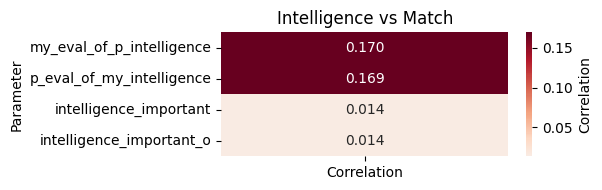

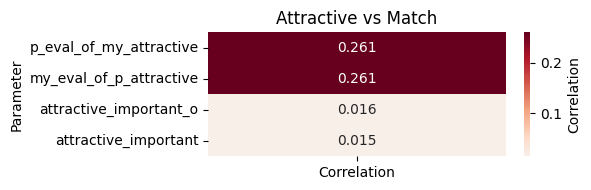

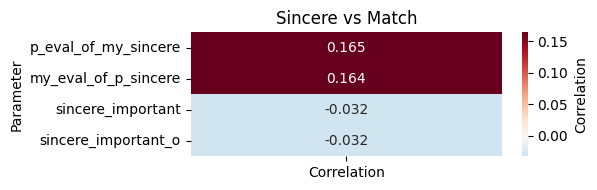

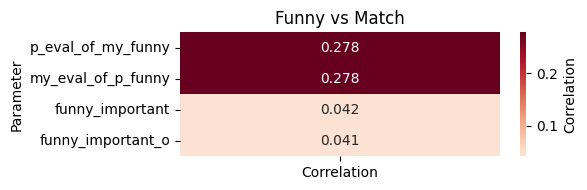

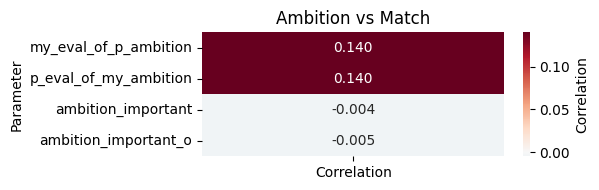

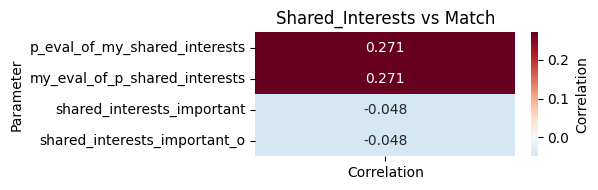

In [65]:
for param in unified_parameters:
    correlations = {}
    for p in unified_parameters[param]:
        if p in cleaned_df.columns:
            correlations[p] = cleaned_df[p].corr(cleaned_df['match'])
            correlations_total[param].append({p: correlations[p]})
    
    if correlations:
        plot_df = pd.DataFrame(list(correlations.items()), 
                             columns=['Parameter', 'Correlation'])
        plot_df = plot_df.sort_values(by='Correlation', ascending=False)
        plot_df = plot_df.set_index('Parameter')
        
        # Heatmap
        plt.figure(figsize=(6, 2))
        sns.heatmap(plot_df, 
                    annot=True, 
                    center=0, 
                    fmt='.3f', 
                    cmap='RdBu_r',
                    cbar_kws={'label': 'Correlation'})
        plt.title(f'{param.title()} vs Match')
        plt.tight_layout()
        plt.show()

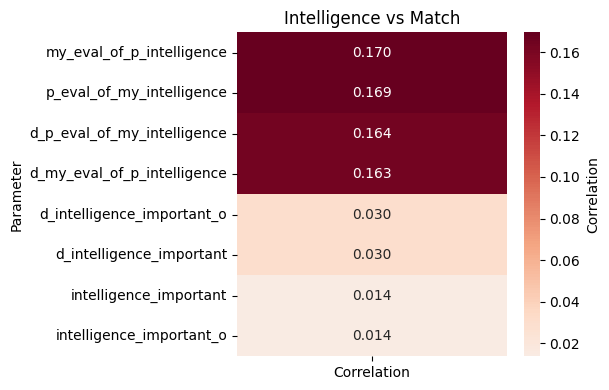

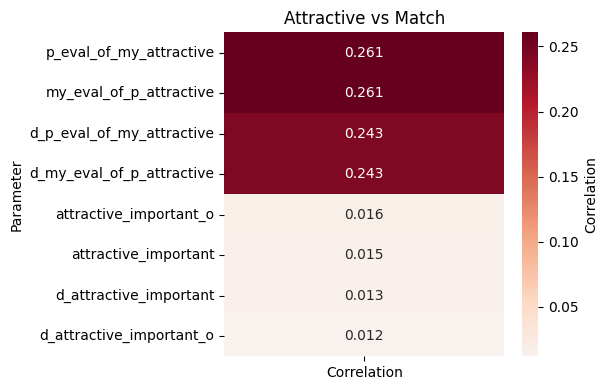

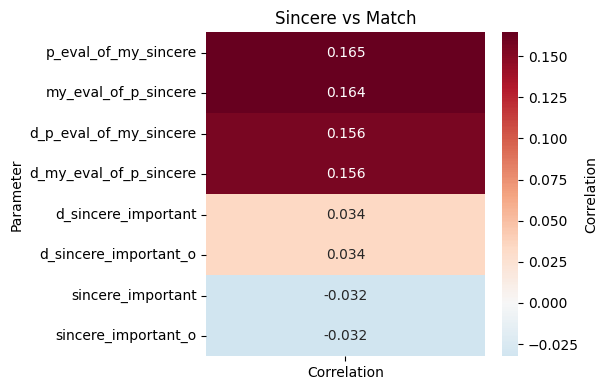

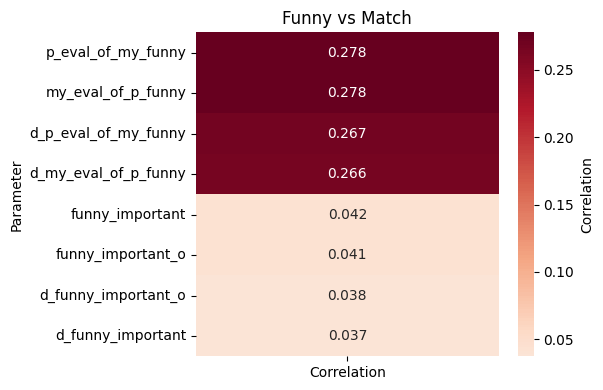

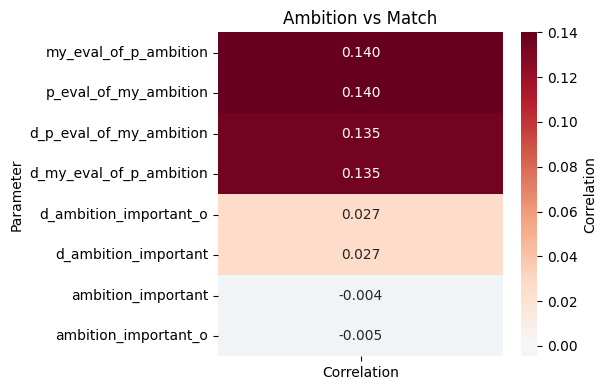

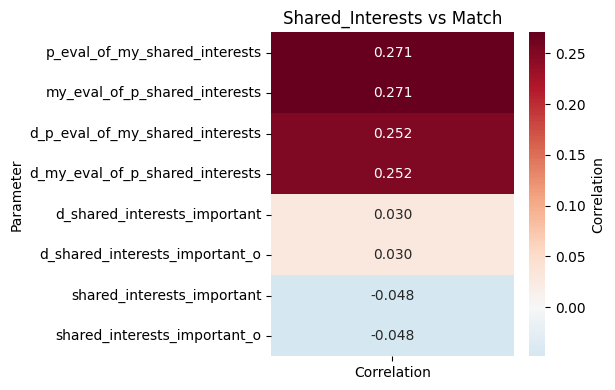

In [66]:
correlations_total

for param in correlations_total:
    flat_correlations = {}
    for item in correlations_total[param]:
        flat_correlations.update(item)
    plot_df = pd.DataFrame(list(flat_correlations.items()), 
                         columns=['Parameter', 'Correlation'])
    plot_df = plot_df.sort_values(by='Correlation', ascending=False)
    plot_df = plot_df.set_index('Parameter')
        
        # Heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(plot_df, 
                    annot=True, 
                    center=0, 
                    fmt='.3f', 
                    cmap='RdBu_r',
                    cbar_kws={'label': 'Correlation'})
    plt.title(f'{param.title()} vs Match')
    plt.tight_layout()
    plt.show()

### Correlation between variables in the groups

Since we have the 8 variable for each parameter, half of which represented by d_, which probably means difference, so we consider to check their correlations too. We assume, that d_ and ordinar variables would have high correlation between them, so we can remove half of the variables, since it is not good to add highly correlated variables. That can lead to the overfitting or some other problems.

#### Encoding of categorical variables

All of our d_ variables are represented by string with ranges, that follows ascending order. Since there is no method, that would calculate the correlaition vetween the string-range categorical variable and numerical one, we consider to encode each ranges variable

In [67]:
for param in unified_d_parameters.values():
  for p in param:
    unique_values = sorted(cleaned_df[p].unique())
    print(f"{p}: {unique_values}")
  print()

d_intelligence_important_o: ['[0-15]', '[16-20]', '[21-100]']
d_intelligence_important: ['[0-15]', '[16-20]', '[21-100]']
d_p_eval_of_my_intelligence: ['[0-5]', '[6-8]', '[9-10]']
d_my_eval_of_p_intelligence: ['[0-5]', '[6-8]', '[9-10]']

d_attractive_important_o: ['[0-15]', '[16-20]', '[21-100]']
d_attractive_important: ['[0-15]', '[16-20]', '[21-100]']
d_p_eval_of_my_attractive: ['[0-5]', '[6-8]', '[9-10]']
d_my_eval_of_p_attractive: ['[0-5]', '[6-8]', '[9-10]']

d_sincere_important_o: ['[0-15]', '[16-20]', '[21-100]']
d_sincere_important: ['[0-15]', '[16-20]', '[21-100]']
d_p_eval_of_my_sincere: ['[0-5]', '[6-8]', '[9-10]']
d_my_eval_of_p_sincere: ['[0-5]', '[6-8]', '[9-10]']

d_funny_important_o: ['[0-15]', '[16-20]', '[21-100]']
d_funny_important: ['[0-15]', '[16-20]', '[21-100]']
d_p_eval_of_my_funny: ['[0-5]', '[6-8]', '[9-10]']
d_my_eval_of_p_funny: ['[0-5]', '[6-8]', '[9-10]']

d_ambition_important_o: ['[0-15]', '[16-20]', '[21-100]']
d_ambition_important: ['[0-15]', '[16-20]'

In [68]:
encoder1 = OrdinalEncoder(categories=[['[0-15]', '[16-20]', '[21-100]']])
encoder2 = OrdinalEncoder(categories=[['[0-5]', '[6-8]', '[9-10]']])

for param in parameters:
  cleaned_df[f"d_{param}_important_o"] = encoder1.fit_transform(cleaned_df[[f"d_{param}_important_o"]])
  cleaned_df[f"d_{param}_important"] = encoder1.fit_transform(cleaned_df[[f"d_{param}_important"]])
  cleaned_df[f"d_p_eval_of_my_{param}"] = encoder2.fit_transform(cleaned_df[[f"d_p_eval_of_my_{param}"]])
  cleaned_df[f"d_my_eval_of_p_{param}"] = encoder2.fit_transform(cleaned_df[[f"d_my_eval_of_p_{param}"]])

In [69]:
for param in unified_d_parameters.values():
  for p in param:
    unique_values = sorted(cleaned_df[p].unique())
    print(f"{p}: {unique_values}")
  print()

d_intelligence_important_o: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
d_intelligence_important: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
d_p_eval_of_my_intelligence: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
d_my_eval_of_p_intelligence: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]

d_attractive_important_o: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
d_attractive_important: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
d_p_eval_of_my_attractive: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
d_my_eval_of_p_attractive: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]

d_sincere_important_o: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
d_sincere_important: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
d_p_eval_of_my_sincere: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
d_my_eval_of_p_sincere: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]

d_funny_important_o: [np.float64(0.0), np.float64(1.0), np.float6

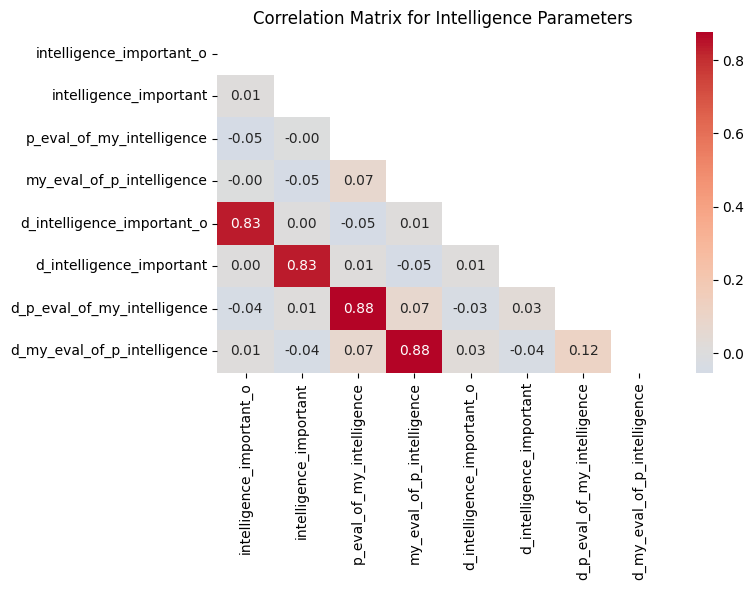

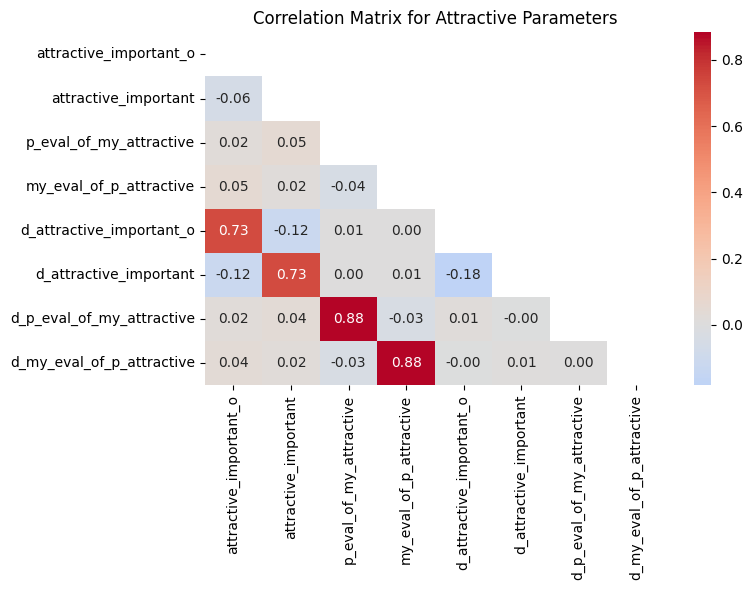

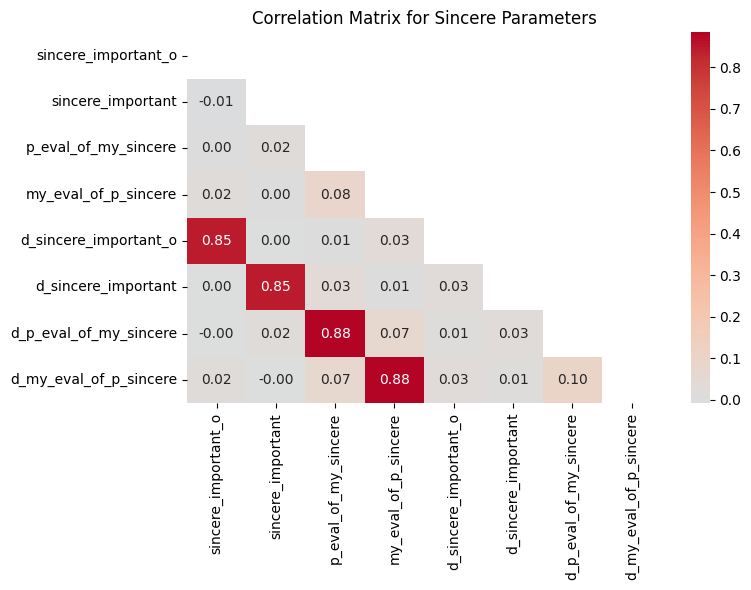

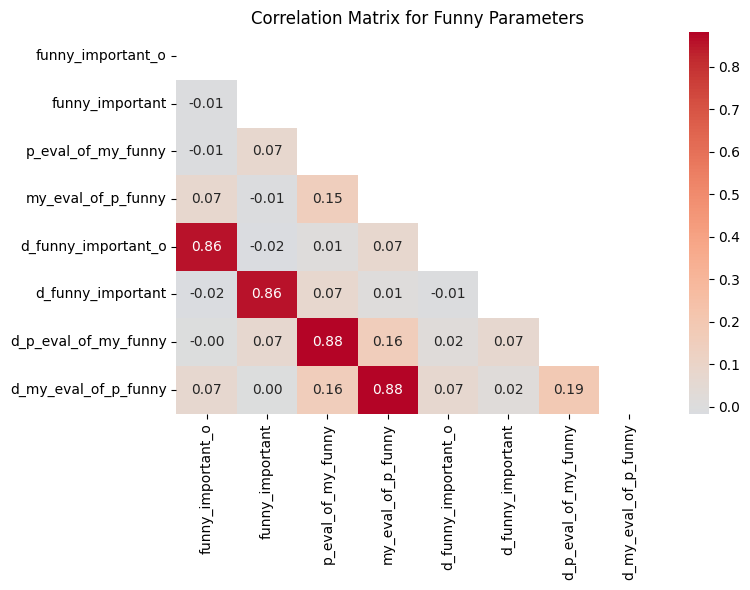

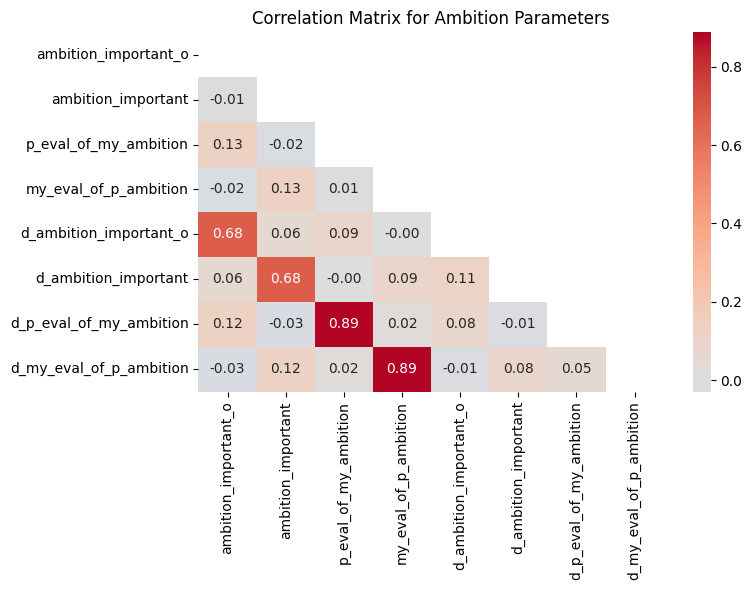

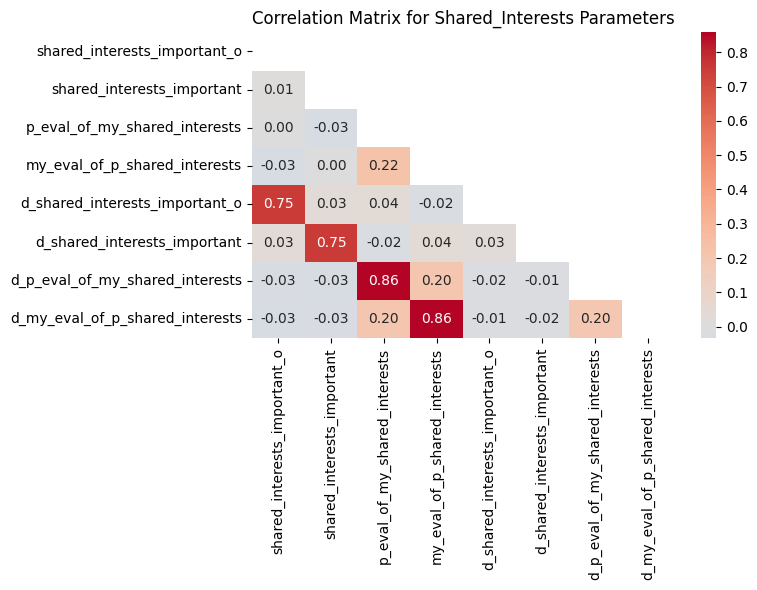

In [70]:
for param in parameters:
  selected_group_columns = []
  selected_group_columns += unified_parameters[param]
  selected_group_columns += unified_d_parameters[param]

  corr_matrix = cleaned_df[selected_group_columns].corr()
  plt.figure(figsize=(8, 6))
  mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
  sns.heatmap(corr_matrix, annot=True, mask=mask, fmt='.2f', cmap='coolwarm', center=0)
  plt.title(f'Correlation Matrix for {param.title()} Parameters')
  plt.tight_layout()
  plt.show()

The theory about the d_ variables and the ordinary one was supported by correlation heatmaps. Each 2 pairs of veriable have high correlation, so we will drop all the variables, represented as d_ variables.The data are represented in more obscure format, which we cannot say with certainty what define.

In [71]:
for param in unified_d_parameters.values():
  cleaned_df.drop(columns=param, inplace=True)

print(cleaned_df.columns.tolist())

['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age', 'race', 'race_o', 'samerace', 'importance_same_race', 'importance_same_religion', 'd_importance_same_race', 'd_importance_same_religion', 'field', 'attractive_important_o', 'sincere_important_o', 'intelligence_important_o', 'funny_important_o', 'ambition_important_o', 'shared_interests_important_o', 'p_eval_of_my_attractive', 'p_eval_of_my_sincere', 'p_eval_of_my_intelligence', 'p_eval_of_my_funny', 'p_eval_of_my_ambition', 'p_eval_of_my_shared_interests', 'attractive_important', 'sincere_important', 'intelligence_important', 'funny_important', 'ambition_important', 'shared_interests_important', 'attractive', 'sincere', 'intelligence', 'funny', 'ambition', 'd_attractive', 'd_sincere', 'd_intelligence', 'd_funny', 'd_ambition', 'my_eval_of_p_attractive', 'my_eval_of_p_sincere', 'my_eval_of_p_intelligence', 'my_eval_of_p_funny', 'my_eval_of_p_ambition', 'my_eval_of_p_shared_interests', 'sports', 'tvsports', 'exercise', 'd

### Clean columns

During analysis we also mentioned, that there are many hobbies and d_hobbies variables, which could easily be replaced with interests_correlate and d_interests_correlate. So we will drop them too

In [72]:
interests_columns = ['sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga', 'd_sports', 'd_tvsports', 'd_exercise', 'd_dining', 'd_museums', 'd_art', 'd_hiking', 'd_gaming', 'd_clubbing', 'd_reading', 'd_tv', 'd_theater', 'd_movies', 'd_concerts', 'd_music', 'd_shopping', 'd_yoga']
cleaned_df.drop(columns=interests_columns, inplace=True)

print(cleaned_df.columns.tolist())

['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age', 'race', 'race_o', 'samerace', 'importance_same_race', 'importance_same_religion', 'd_importance_same_race', 'd_importance_same_religion', 'field', 'attractive_important_o', 'sincere_important_o', 'intelligence_important_o', 'funny_important_o', 'ambition_important_o', 'shared_interests_important_o', 'p_eval_of_my_attractive', 'p_eval_of_my_sincere', 'p_eval_of_my_intelligence', 'p_eval_of_my_funny', 'p_eval_of_my_ambition', 'p_eval_of_my_shared_interests', 'attractive_important', 'sincere_important', 'intelligence_important', 'funny_important', 'ambition_important', 'shared_interests_important', 'attractive', 'sincere', 'intelligence', 'funny', 'ambition', 'd_attractive', 'd_sincere', 'd_intelligence', 'd_funny', 'd_ambition', 'my_eval_of_p_attractive', 'my_eval_of_p_sincere', 'my_eval_of_p_intelligence', 'my_eval_of_p_funny', 'my_eval_of_p_ambition', 'my_eval_of_p_shared_interests', 'interests_correlate', 'd_interests_

In [73]:
def plot_distributions(df):
  columns = df.select_dtypes(include=['number']).columns.tolist()

  col_num = 3
  row_num = math.ceil(len(columns) / col_num)

  _, axes = plt.subplots(nrows = row_num, ncols = col_num, figsize=(20, 4 * row_num))
  axes = axes.flatten()

  for i, col in enumerate(columns):
      sns.histplot(df[col], ax=axes[i], linewidth=0.3)
      axes[i].set_title(f'Distribution of {col}', fontsize=8)
      axes[i].set_xlabel(col, fontsize=8)
      axes[i].set_ylabel("Count", fontsize=8)

  plt.subplots_adjust(hspace=0.75, wspace=0.3)
  plt.tight_layout()
  plt.show()

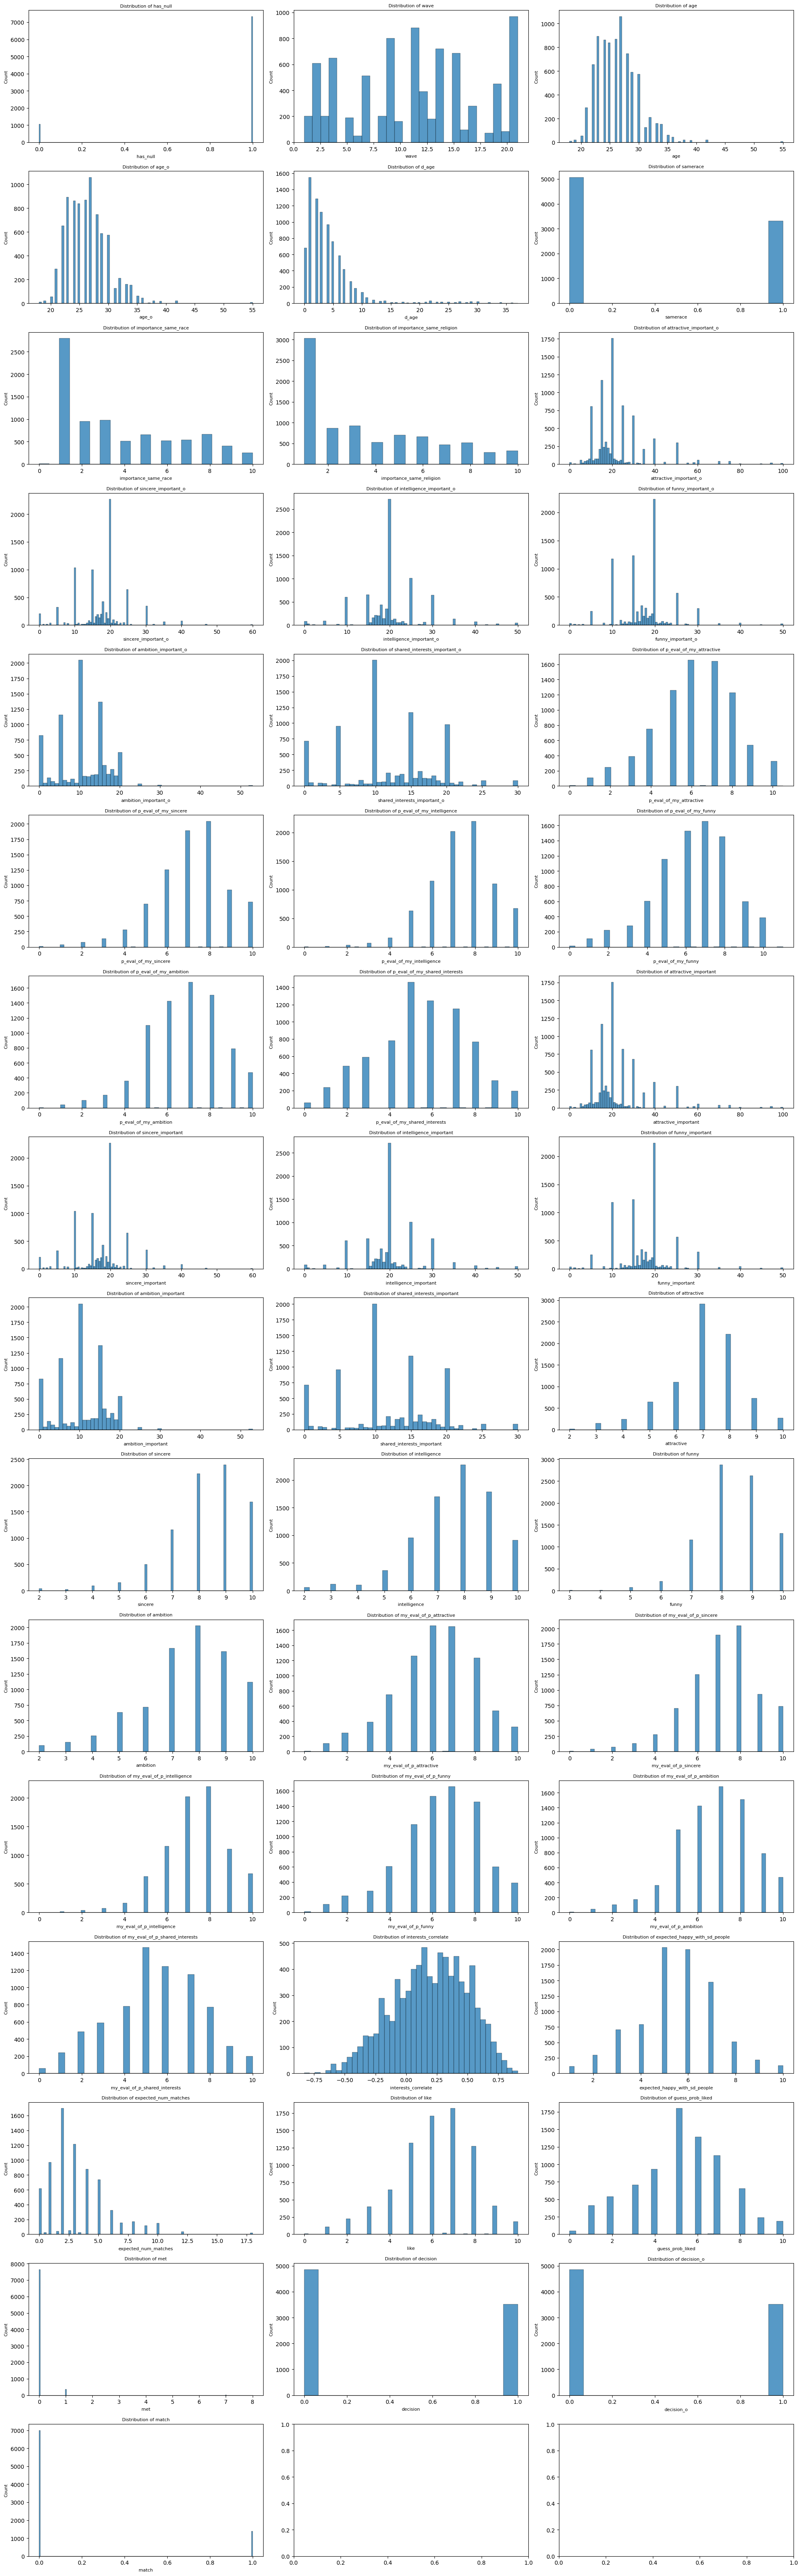

In [74]:
plot_distributions(cleaned_df)

In [75]:
cleaned_df[cleaned_df['met'] == 3]['met'].count()

np.int64(1)

In [76]:
cleaned_df['has_null'].groupby(cleaned_df['has_null']).agg("count")
cleaned_df['has_null'].unique()

array([0, 1])

We've spotted some issues with data:\
1. Met should be represented as binary variable, but somehow there appear 1 record with met == 3, which cannot be. Since it is only 1 record we will simply remove it

In [77]:
cleaned_df = cleaned_df.drop(cleaned_df[cleaned_df['met'] == 3].index)
cleaned_df[cleaned_df['met'] == 3]['met'].count()

np.int64(0)

## Analyse numerical data

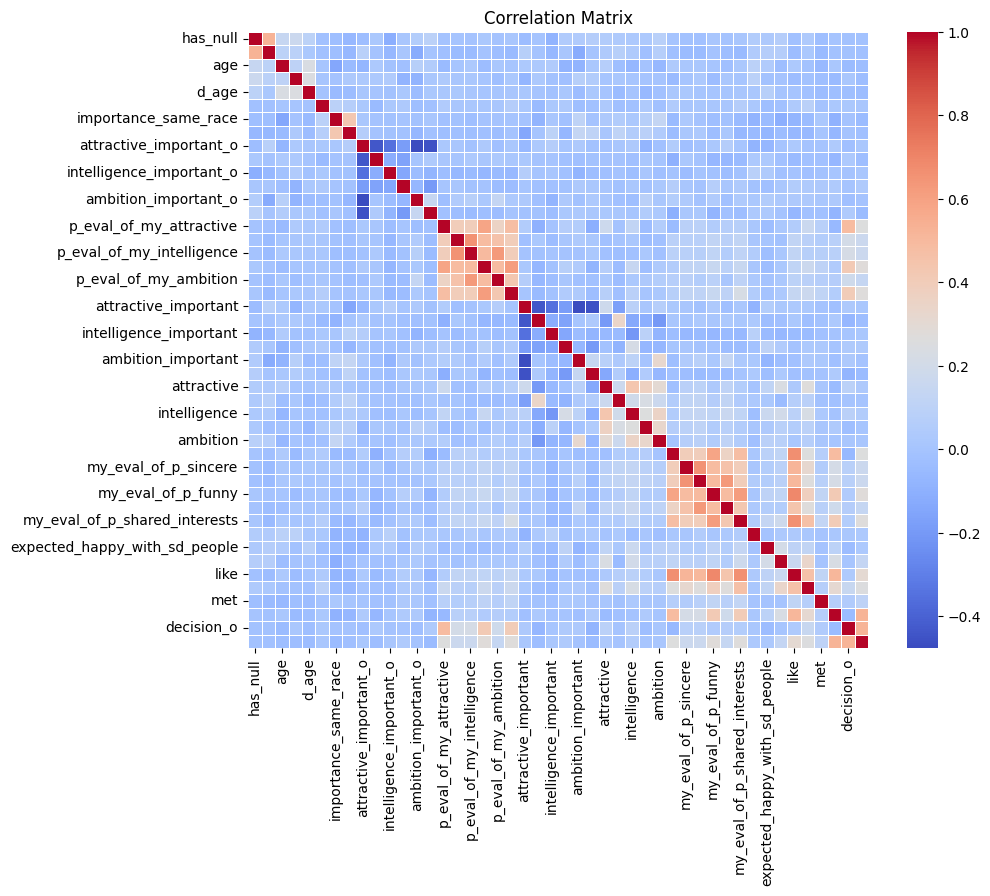

In [78]:
numeric_columns = cleaned_df.select_dtypes(include=['number']).columns
correlation_matrix = cleaned_df[numeric_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

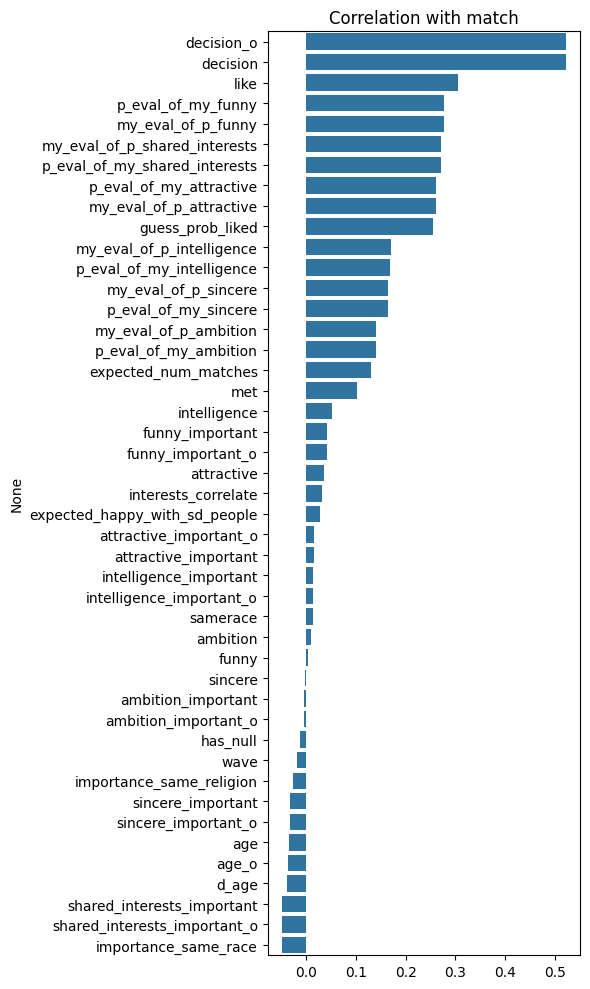

In [79]:
numeric_columns = cleaned_df.select_dtypes(include=['number']).columns
corr_match = cleaned_df[numeric_columns].corr()['match'].drop('match').sort_values(ascending=False)

plt.figure(figsize=(6, 10))
sns.barplot(x=corr_match.values, y=corr_match.index)
plt.title('Correlation with match')
plt.tight_layout()
plt.show()

In [80]:
numerical_columns = cleaned_df.select_dtypes(include=['number'])
groupby_match = numerical_columns.groupby("match").agg("count")
groupby_match

,has_null,wave,age,age_o,d_age,samerace,importance_same_race,importance_same_religion,attractive_important_o,sincere_important_o,...,my_eval_of_p_ambition,my_eval_of_p_shared_interests,interests_correlate,expected_happy_with_sd_people,expected_num_matches,like,guess_prob_liked,met,decision,decision_o
match,,,,,,,,,,,,,,,,,,,,,
0,6997,6997,6920,6911,6997,6997,6933,6933,6923,6923,...,6363,6050,6869,6912,6059,6761,6702,6655,6997,6997
1,1380,1380,1362,1362,1380,1380,1365,1365,1365,1365,...,1302,1260,1350,1364,1145,1376,1366,1347,1380,1380


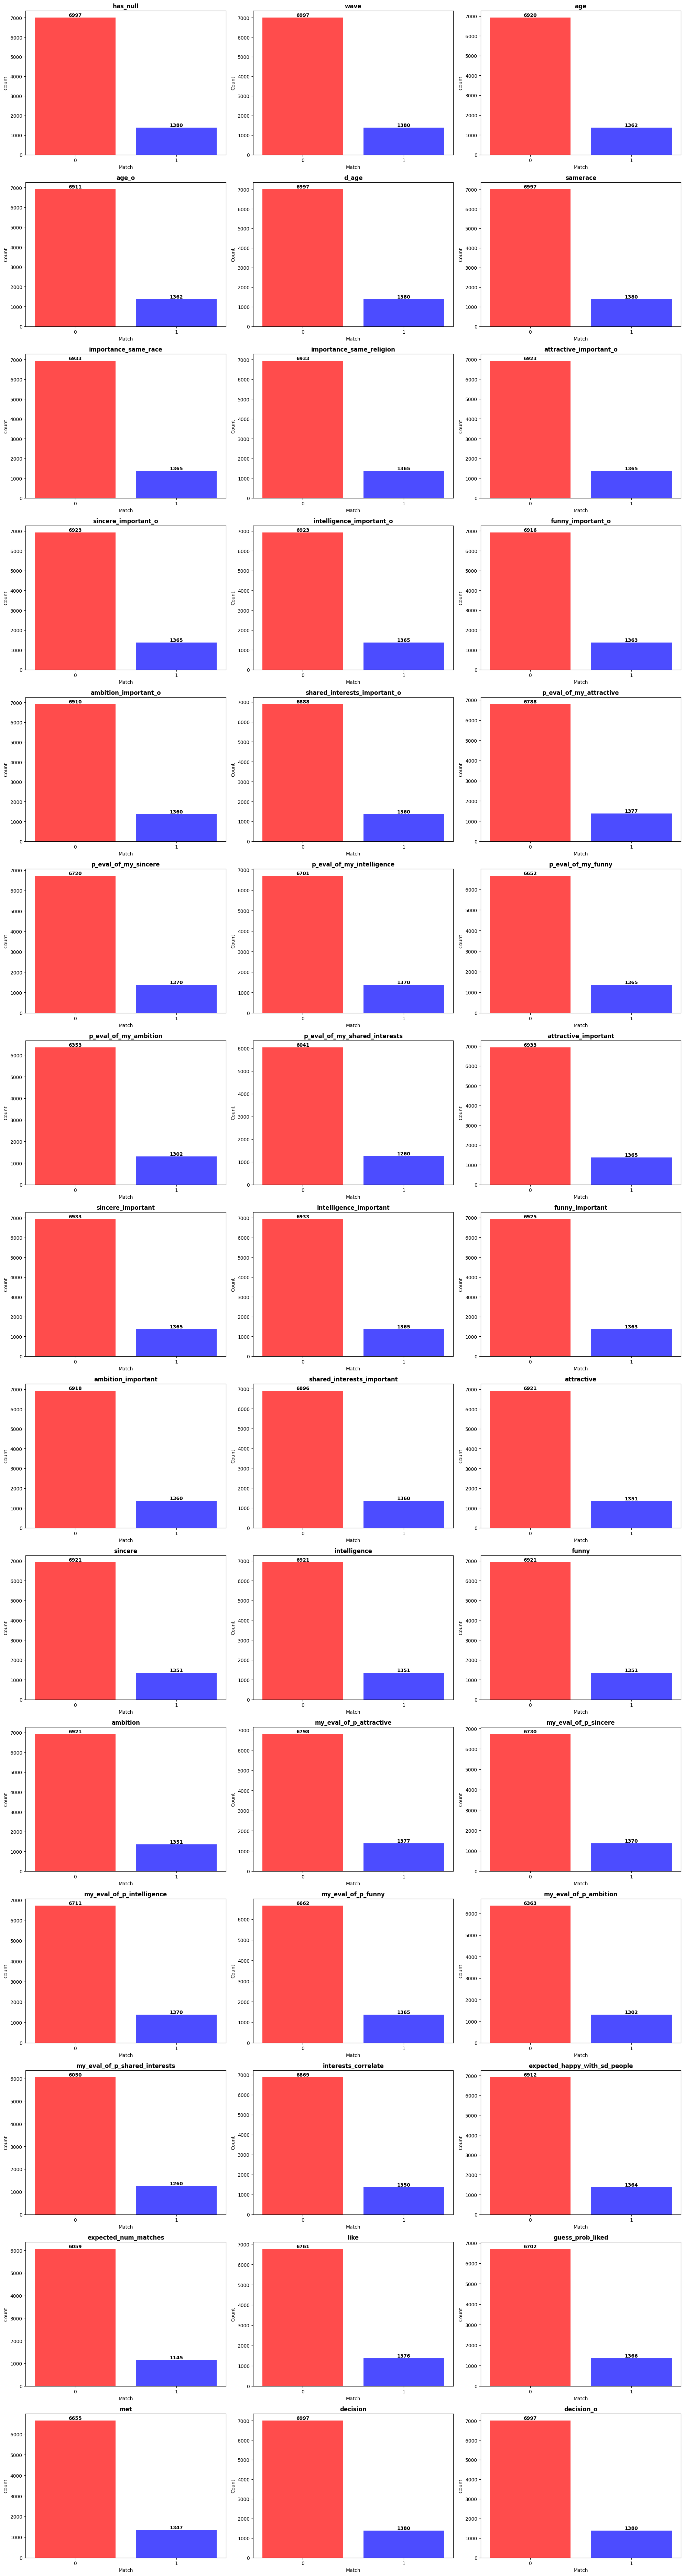

In [81]:
if 'match' in numerical_columns.columns:
    plot_columns = numerical_columns.columns.drop('match')
else:
    plot_columns = numerical_columns.columns

n_cols = 3
n_rows = math.ceil(len(plot_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_columns):
    counts = cleaned_df.groupby('match')[col].apply(lambda x: x.notna().sum())

    bars = axes[i].bar(counts.index, counts.values, color=['red', 'blue'], alpha=0.7)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel('Match')
    axes[i].set_ylabel('Count')
    axes[i].set_xticks([0, 1])

    for bar, count in zip(bars, counts.values):
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{count}', ha='center', va='bottom', fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()